In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.util import ngrams



In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
df=pd.read_csv('/content/drive/MyDrive/AI Resume Analyzer Dataset/resume_data (1).csv')
print(df.head(),"\n")

                 Category                                             Resume
0         DevOps Engineer  Competencies VISA B1-VISA (USA) Onsite Visits ...
1      Operations Manager  KEY COMPETENCIES ✶Multi - Operations Managemen...
2                 Testing  COMPUTER PROFICIENCY • Basic: MS-Office (Power...
3  Electrical Engineering  Education Details \nJanuary 2012 to January 20...
4          Java Developer  TECHNICAL SKILLS Skills: Java, SQL, PL/SQL, C,... 



In [5]:
print(df.info(),"\n")
print(df.describe(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  12000 non-null  object
 1   Resume    12000 non-null  object
dtypes: object(2)
memory usage: 187.6+ KB
None 

              Category                                             Resume
count            12000                                              12000
unique              25                                              12000
top     Java Developer  Competencies: - 1) Team leading 2) Self-motiva...
freq              1048                                                  1 



# Exploring Categories

In [6]:
df['Category'].value_counts()

,count
Category,
Java Developer,1048
Testing,873
DevOps Engineer,686
Python Developer,599
Web Designing,561
HR,549
Hadoop,524
Data Science,499
Operations Manager,499


/tmp/ipykernel_1464/1335681137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


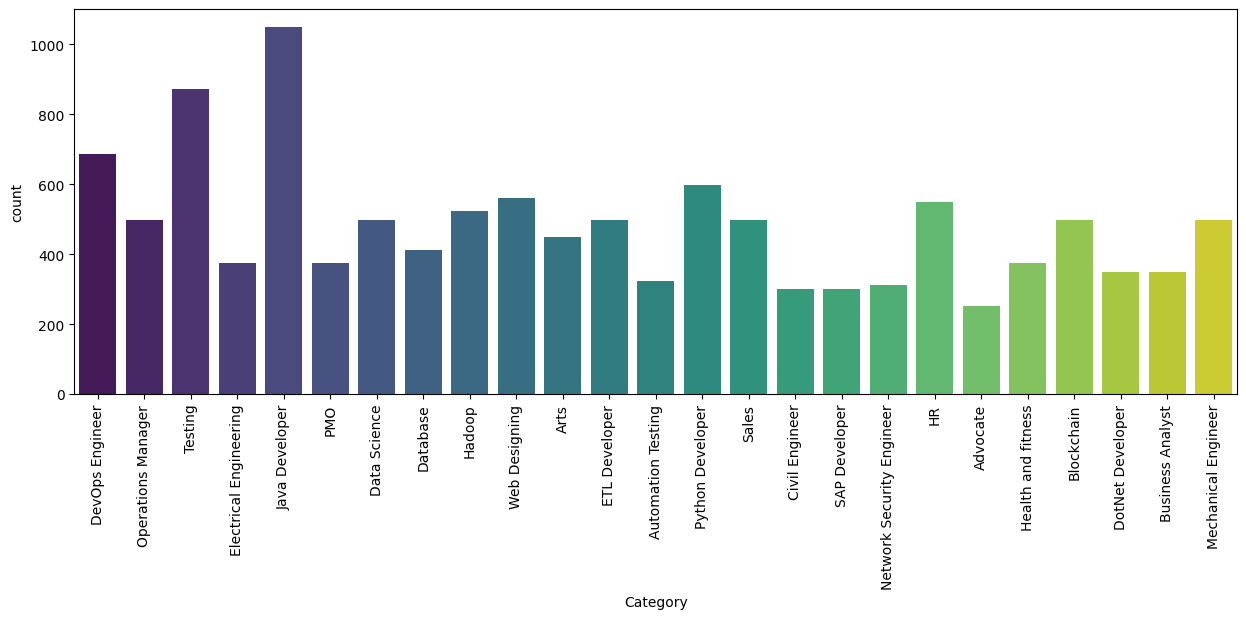

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
sns.countplot(data=df, x='Category', palette='viridis')
plt.xticks(rotation=90)
plt.show()

In [8]:
df['Category'].unique()

array(['DevOps Engineer', 'Operations Manager', 'Testing',
       'Electrical Engineering', 'Java Developer', 'PMO', 'Data Science',
       'Database', 'Hadoop', 'Web Designing', 'Arts', 'ETL Developer',
       'Automation Testing', 'Python Developer', 'Sales',
       'Civil Engineer', 'SAP Developer', 'Network Security Engineer',
       'HR', 'Advocate', 'Health and fitness', 'Blockchain',
       'DotNet Developer', 'Business Analyst', 'Mechanical Engineer'],
      dtype=object)

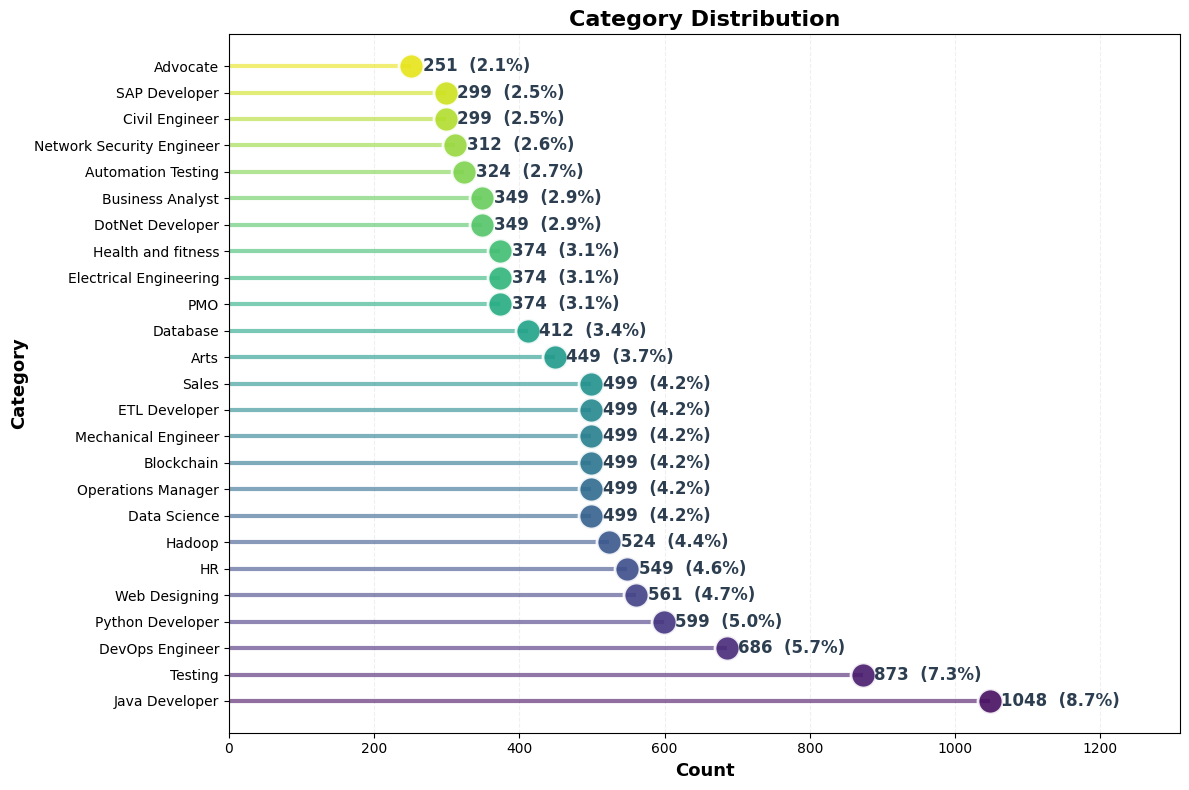

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
category_counts = df['Category'].value_counts()
total = len(df)
plt.figure(figsize=(12, 8))
colors = sns.color_palette("viridis", len(category_counts))
for i, (category, count) in enumerate(category_counts.items()):
    plt.hlines(y=category, xmin=0, xmax=count, color=colors[i], linewidth=3, alpha=0.6)
    plt.plot(count, category, 'o', markersize=18, color=colors[i], alpha=0.9,
             markeredgecolor='white', markeredgewidth=2)
for i, (category, count) in enumerate(category_counts.items()):
    percentage = (count/total)*100
    plt.text(count + (max(category_counts) * 0.015),
             category,
             f'{count}  ({percentage:.1f}%)',
             va='center',
             fontsize=12,
             fontweight='bold',
             color='#2c3e50')

plt.xlabel('Count', fontsize=13, fontweight='bold')
plt.ylabel('Category', fontsize=13, fontweight='bold')
plt.title('Category Distribution', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.2, linestyle='--')
plt.xlim(0, max(category_counts) * 1.25)
plt.tight_layout()
plt.show()

# Exploring Resume

In [10]:
df['Category'][0]

'DevOps Engineer'

In [11]:
df['Resume'][0]

'Competencies VISA B1-VISA (USA) Onsite Visits to Sweden & US (Seattle) Education Details \nJanuary 2013 Post Graduate Diploma Information Technology Pune, Maharashtra Symbiosis Institute\nJanuary 2007 Bachelor of Engineering Electronics and Telecommunications Pune, Maharashtra Pune University\nCloud Operations Architect (DevOps) \n\nCloud Operations Architect (DevOps) - DevOps\nSkill Details \nCloud Computing- Exprience - 48 months\nShell Scripting- Exprience - 96 months\nPython- Exprience - 6 months\nAutomation- Exprience - 72 months\nSolution Architect- Exprience - Less than 1 year months\nAzure- Exprience - Less than 1 year months\nAWS- Exprience - Less than 1 year monthsCompany Details \ncompany - DevOps\ndescription - Type: DevOps Engineer.\nPlatform: AWS Cloud, Azure Cloud.\nServices: AWS EC2, RDS, CloudFormation Template, Lambda, Dynamo DB,\t\tCloud Watch, Auto-scaling, Elastic Bean stalk, Appdynamics.\n\nHere I manage Tibco Spotfire enterprise & Cloud Product support. Being th

# Resume length analysis

In [12]:
df['text_length'] = df['Resume'].str.len()
df['word_count'] = df['Resume'].str.split().str.len()
df['sentence_count'] = df['Resume'].str.split('[.!?]').str.len() - 1
stats_by_category = df.groupby('Category').agg({
    'text_length': ['mean', 'std', 'min', 'max'],
    'word_count': ['mean', 'std', 'min', 'max'],
    'sentence_count': ['mean', 'std', 'min', 'max']
}).round(2)

print(stats_by_category)

                          text_length                       word_count  \
                                 mean      std   min    max       mean   
Category                                                                 
Advocate                      1296.13   848.33   176   2814     191.40   
Arts                          3819.36  3260.68   408   8372     528.63   
Automation Testing            3953.71  1580.99   836   6703     569.11   
Blockchain                    2320.83   760.37  1318   3460     331.40   
Business Analyst              4314.15  3606.51  1522  11385     623.72   
Civil Engineer                3875.73  1816.72   476   6929     556.21   
Data Science                  4136.13  2461.54   437   8023     605.21   
Database                      3786.17   972.51  2004   5809     541.58   
DevOps Engineer               4472.24  1892.41  1563   8257     648.05   
DotNet Developer              3198.19  2664.50   433   8495     480.73   
ETL Developer                 3658.94 

# Cleaning data: URLs, Hashtags, Mentions, Special letters, Punctuations

In [13]:
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def cleanResume(txt):

    if not isinstance(txt, str):
        return ""
    txt = txt.lower()
    txt = re.sub(r'http\S+|www\S+|https\S+', ' ', txt)
    txt = re.sub(r'@\S+', ' ', txt)
    txt = re.sub(r'#\S+', ' ', txt)
    txt = re.sub(r'\brt\b', ' ', txt, flags=re.IGNORECASE)
    txt = re.sub(r'[^a-zA-Z0-9\s\-/._]', ' ', txt)
    txt = re.sub(r'[^\x00-\x7f]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()

    return txt

In [15]:
df['cleaned_resume']= df['Resume'].apply(lambda x: cleanResume(x))

In [16]:
df['resume_length']= df['cleaned_resume'].apply(lambda x: len(x.split()))

In [17]:
df['Resume'][0]

'Competencies VISA B1-VISA (USA) Onsite Visits to Sweden & US (Seattle) Education Details \nJanuary 2013 Post Graduate Diploma Information Technology Pune, Maharashtra Symbiosis Institute\nJanuary 2007 Bachelor of Engineering Electronics and Telecommunications Pune, Maharashtra Pune University\nCloud Operations Architect (DevOps) \n\nCloud Operations Architect (DevOps) - DevOps\nSkill Details \nCloud Computing- Exprience - 48 months\nShell Scripting- Exprience - 96 months\nPython- Exprience - 6 months\nAutomation- Exprience - 72 months\nSolution Architect- Exprience - Less than 1 year months\nAzure- Exprience - Less than 1 year months\nAWS- Exprience - Less than 1 year monthsCompany Details \ncompany - DevOps\ndescription - Type: DevOps Engineer.\nPlatform: AWS Cloud, Azure Cloud.\nServices: AWS EC2, RDS, CloudFormation Template, Lambda, Dynamo DB,\t\tCloud Watch, Auto-scaling, Elastic Bean stalk, Appdynamics.\n\nHere I manage Tibco Spotfire enterprise & Cloud Product support. Being th

# Resume Length Distribution

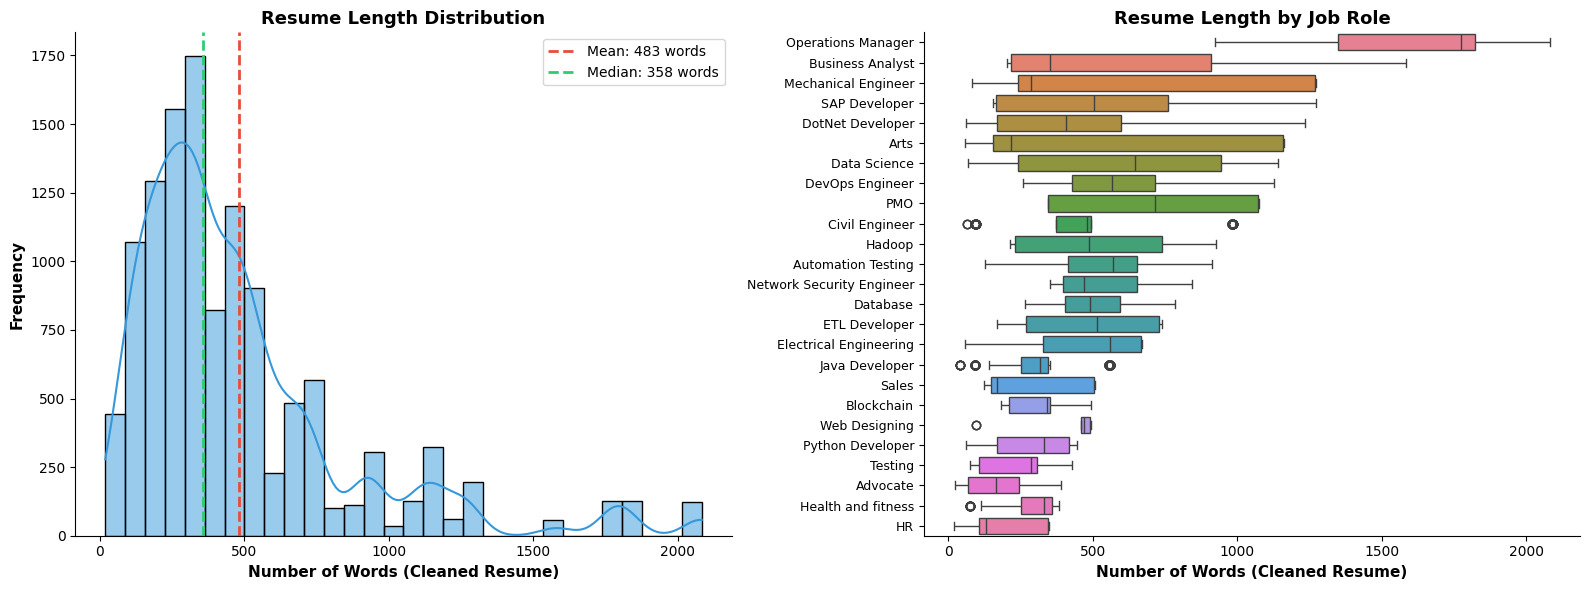


Resume Length Statistics:
   Mean   : 482.6 words
   Median : 358.0 words
   Min    : 19 words
   Max    : 2083 words
   Std    : 384.0 words


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Histogram with KDE ---
ax1 = axes[0]
sns.histplot(data=df, x='resume_length', bins=30, kde=True, color='#3498db', ax=ax1)
ax1.axvline(df['resume_length'].mean(), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Mean: {df["resume_length"].mean():.0f} words')
ax1.axvline(df['resume_length'].median(), color='#2ecc71', linestyle='--', linewidth=2,
            label=f'Median: {df["resume_length"].median():.0f} words')
ax1.set_xlabel('Number of Words (Cleaned Resume)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Resume Length Distribution', fontsize=13, fontweight='bold') # Removed emoji
ax1.legend(fontsize=10)
sns.despine(ax=ax1)

# --- Right: Box plot by job role ---
ax2 = axes[1]
df_sorted = df.sort_values('resume_length', ascending=False)
sns.boxplot(data=df_sorted, y='Category', x='resume_length', hue='Category', palette='husl', legend=False, ax=ax2) # Added hue and legend=False
ax2.set_xlabel('Number of Words (Cleaned Resume)', fontsize=11, fontweight='bold')
ax2.set_ylabel('')
ax2.set_title('Resume Length by Job Role', fontsize=13, fontweight='bold') # Removed emoji
ax2.tick_params(axis='y', labelsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nResume Length Statistics:")
print(f"   Mean   : {df['resume_length'].mean():.1f} words")
print(f"   Median : {df['resume_length'].median():.1f} words")
print(f"   Min    : {df['resume_length'].min()} words")
print(f"   Max    : {df['resume_length'].max()} words")
print(f"   Std    : {df['resume_length'].std():.1f} words")

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
from sklearn.metrics.pairwise import cosine_similarity as _cos
from scipy.sparse.csgraph import connected_components as _cc
from scipy.sparse import csr_matrix as _csr
import numpy as _np

df = df.drop_duplicates(subset='cleaned_resume').reset_index(drop=True)  # still drop exact dups, cheap and harmless

THRESH = 0.85
df['cluster_id'] = pd.Series([""] * len(df), dtype=object)

for cat, group in df.groupby('Category'):
    idx = group.index.to_numpy()
    texts = group['cleaned_resume'].tolist()
    vec = _TV(max_features=3000).fit_transform(texts)
    sim = _cos(vec)
    sim[sim < THRESH] = 0
    _np.fill_diagonal(sim, 0)
    n_comp, labels = _cc(_csr(sim), directed=False)
    for i, local_idx in enumerate(idx):
        df.at[local_idx, 'cluster_id'] = f"{cat}_{labels[i]}"

print(f"Rows: {len(df)}  |  Unique near-duplicate template clusters: {df['cluster_id'].nunique()}")
print("If this number is small relative to row count, most of your 'diversity' is paraphrase noise, not real variation.")


Rows: 11861  |  Unique near-duplicate template clusters: 166
If this number is small relative to row count, most of your 'diversity' is paraphrase noise, not real variation.


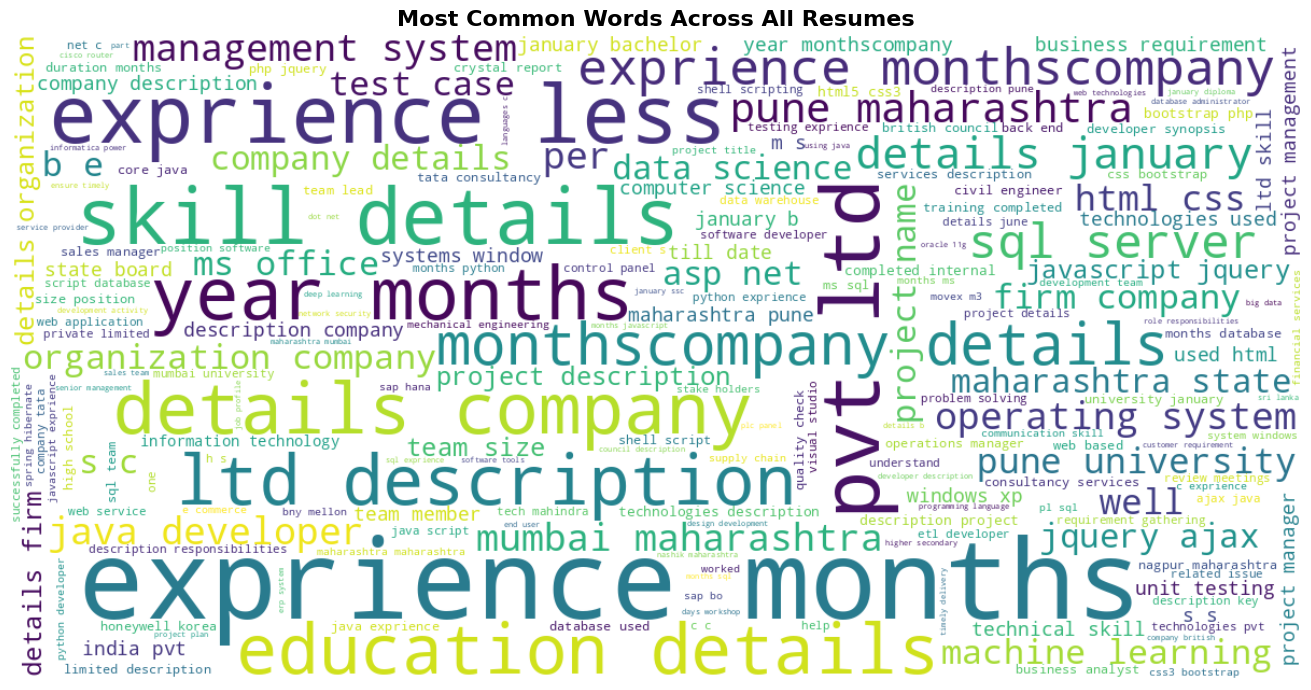

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text= ' '.join(df['cleaned_resume'])

wordcloud= WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=None,
    max_words=200,
    colormap='viridis'
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words Across All Resumes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Create Numeric Dataframe for Correlation analysis

Library load done!
 numeric_df is creating..

 Data Cleaning is running...
⚠️ experience_years-Highest value 300 to 40- (because greater than 40 is not good)।

 numeric_df done! see 5 row below:
   word_count  char_count  avg_word_length  num_sentences  num_unique_words  \
0         714        4559         5.459384             52               312   
1         956        6547         5.881799             32               425   
2         301        1902         5.365449             13               158   
3         337        2215         5.608309             12               196   
4         343        2202         5.472303             17               203   

   stopword_ratio  skill_count  experience_years  positive_sentiment  \
0        0.208683           16                 2               0.078   
1        0.207113            7                 0               0.124   
2        0.239203            6                 1               0.081   
3        0.186944            3            

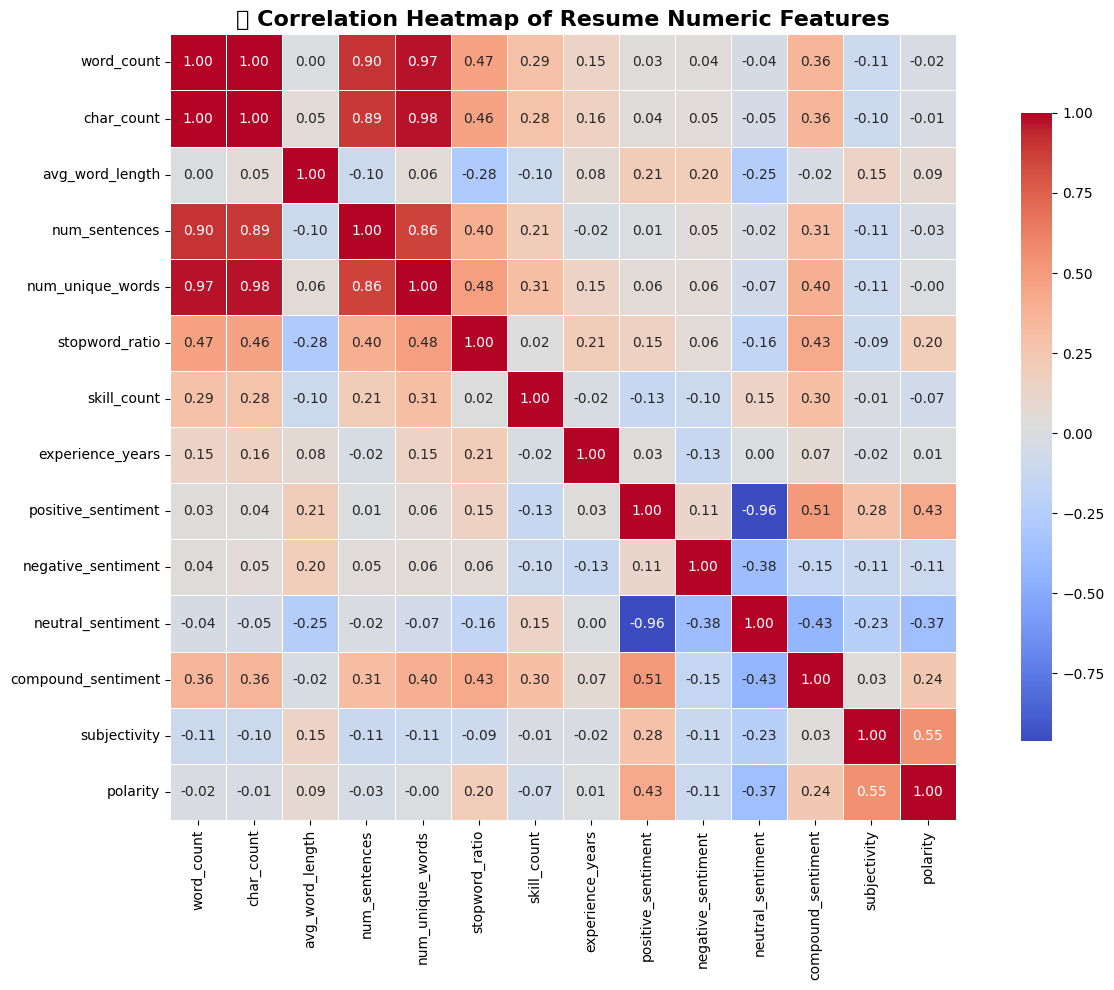

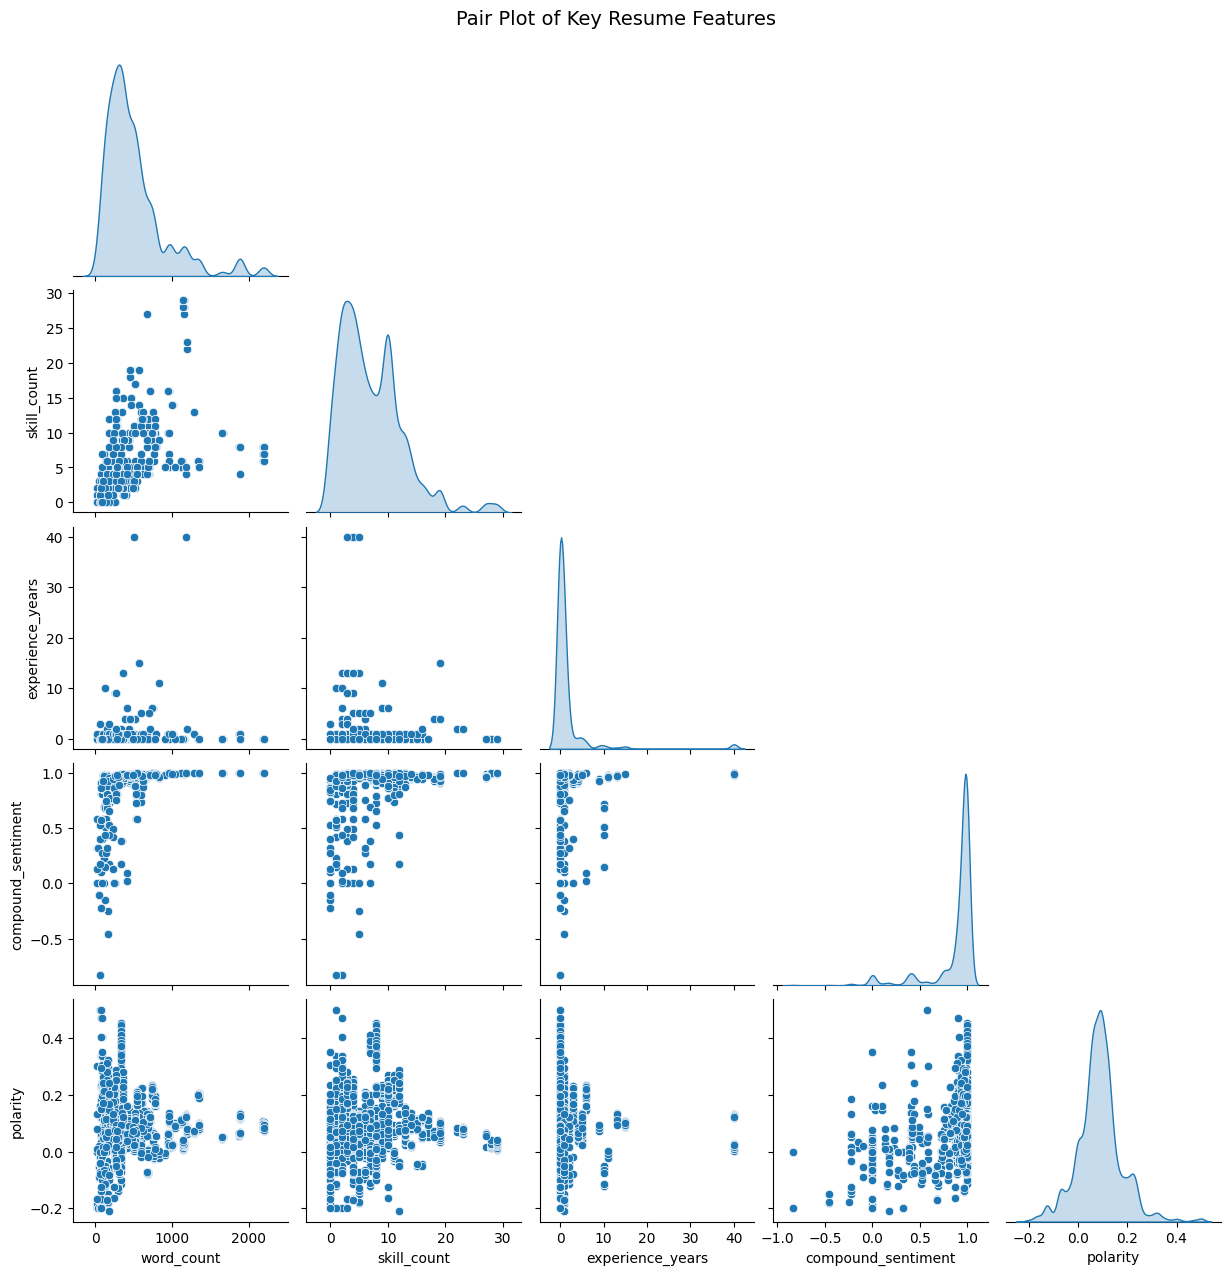


See every distribution:


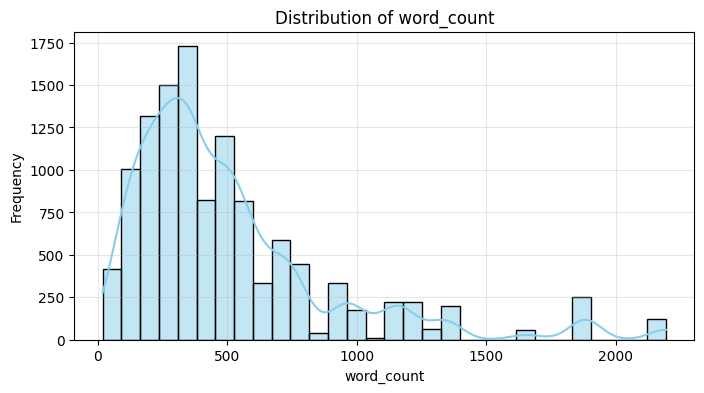

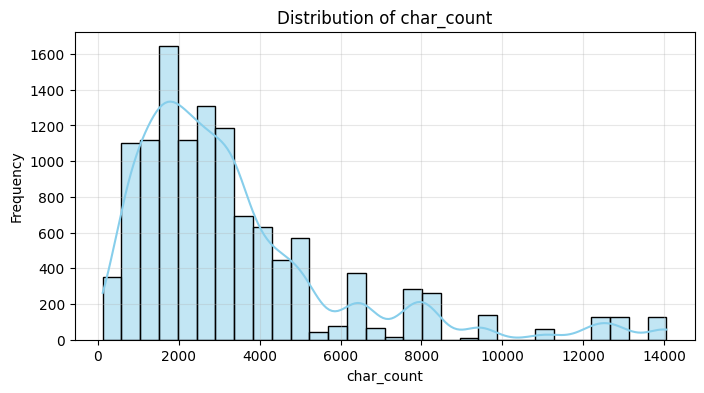

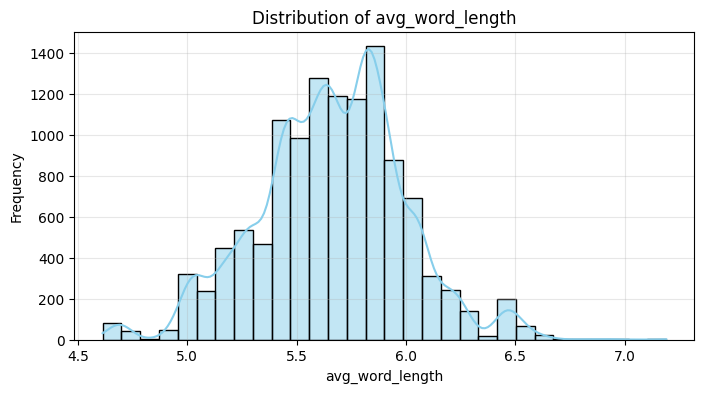

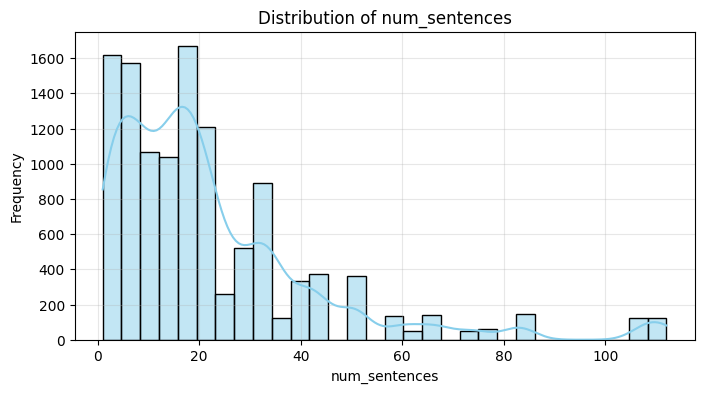

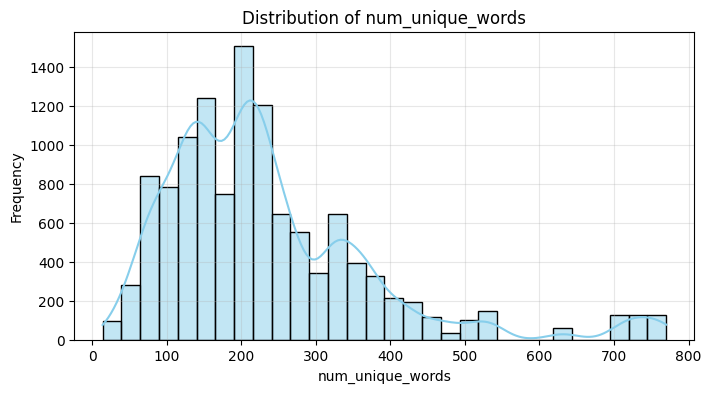

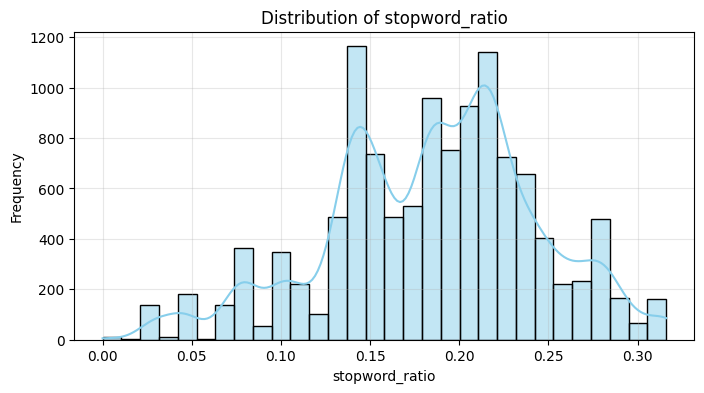

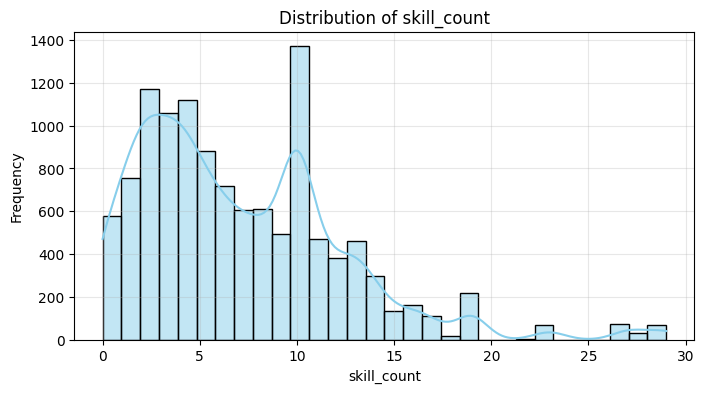

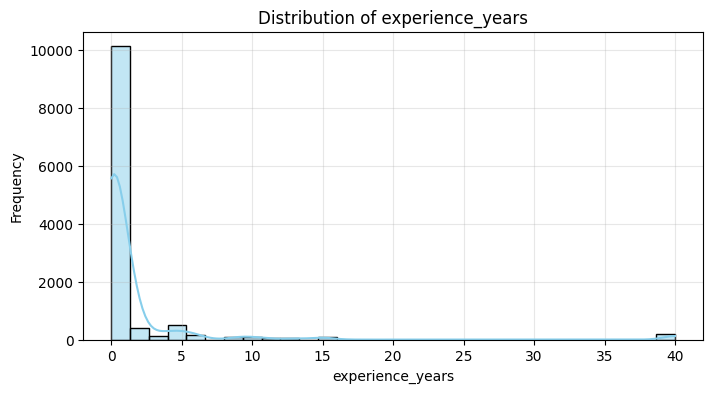

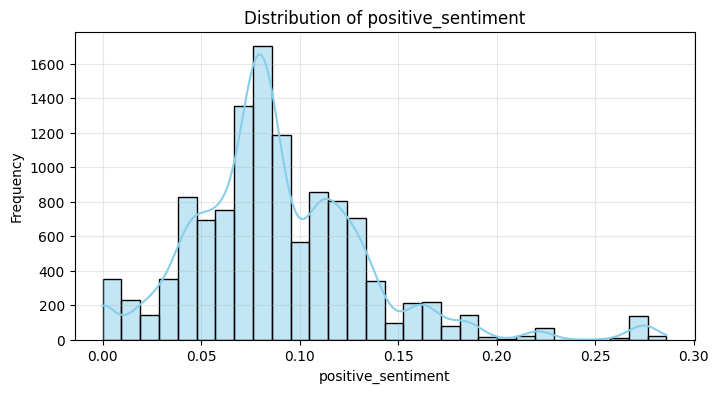

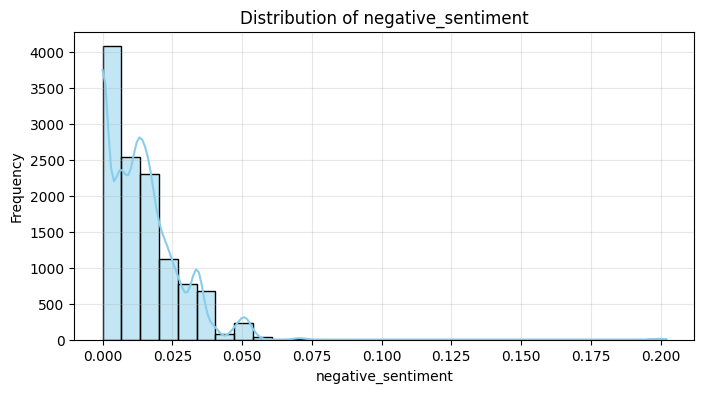

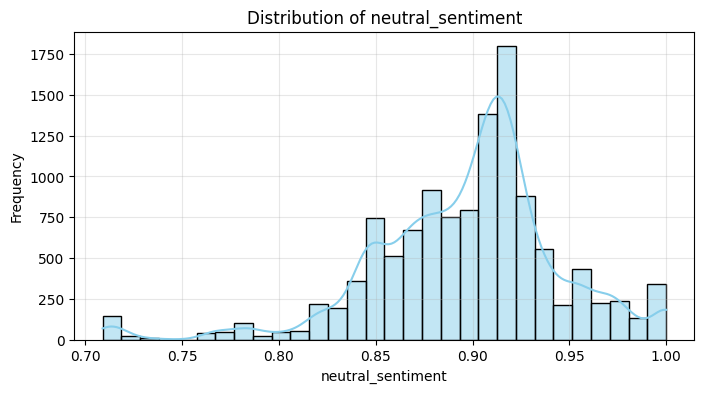

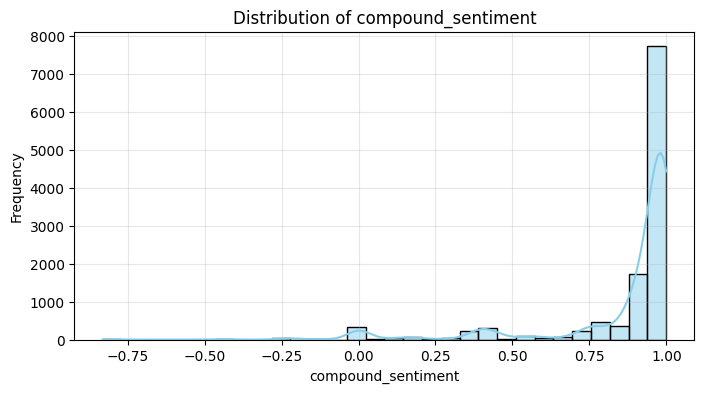

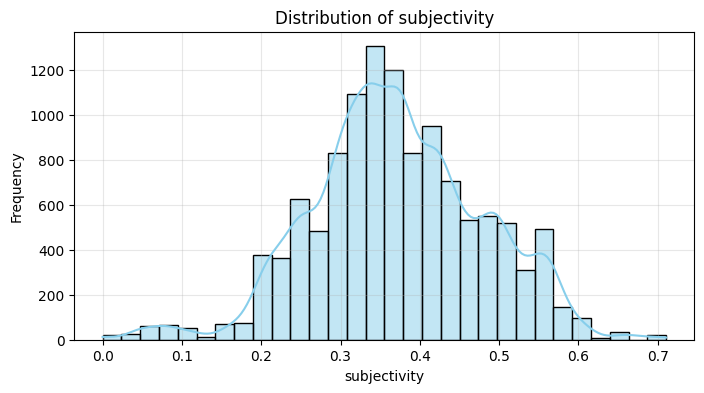

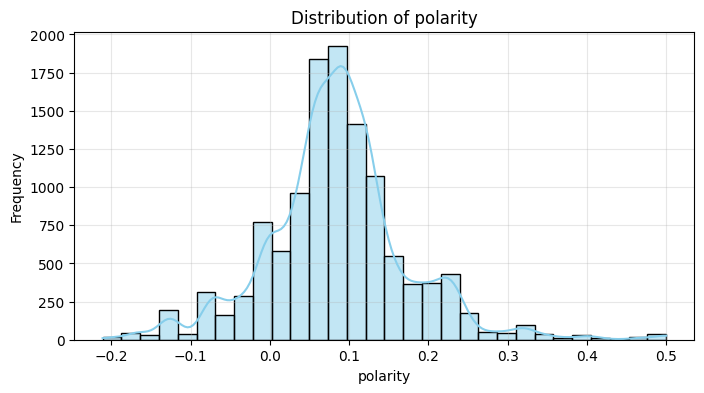

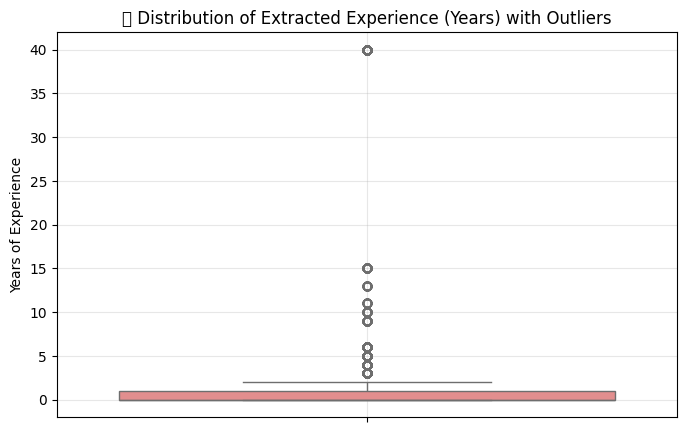

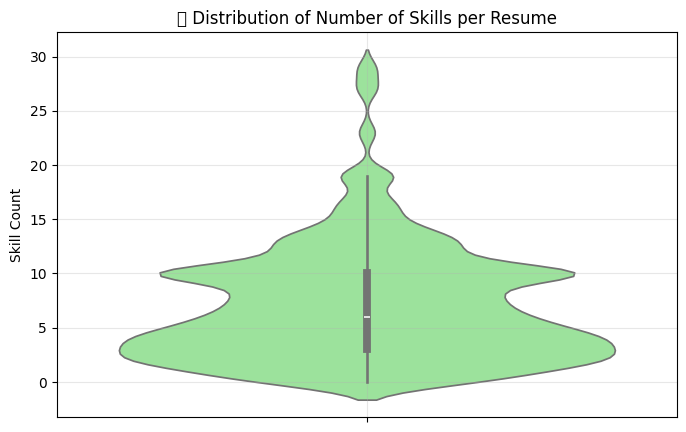

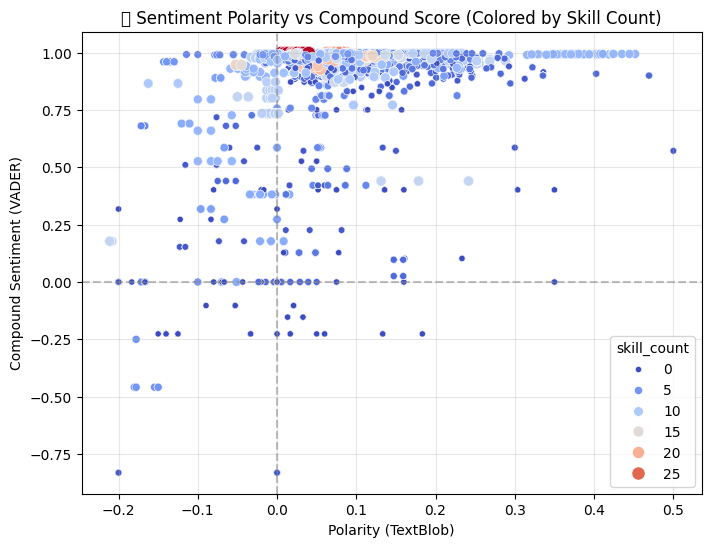


 Every EDA plot done!Everything is alright .


In [20]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

print("Library load done!")

SKILLS_DB = [

    'python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'php', 'ruby', 'go', 'rust',
    'sql', 'mysql', 'postgresql', 'mongodb', 'oracle', 'nosql', 'sql server',

    'html', 'css', 'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'spring boot',
    'asp.net', 'rails', 'laravel', 'bootstrap', 'jquery',

    'machine learning', 'deep learning', 'nlp', 'computer vision', 'data science', 'data analysis',
    'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'matplotlib', 'seaborn',
    'tableau', 'power bi', 'excel', 'data visualization', 'statistics',

    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'linux', 'bash', 'terraform',
    'ansible', 'prometheus', 'grafana', 'ci/cd', 'devops',

    'agile', 'scrum', 'project management', 'leadership', 'team management', 'communication',
    'problem solving', 'critical thinking', 'time management', 'collaboration', 'decision making',

    'cybersecurity', 'network security', 'penetration testing', 'ethical hacking', 'security',

    'sap', 'salesforce', 'erp', 'blockchain', 'iot', 'robotics', 'automation', 'testing', 'qa'
]

def extract_skills_rule_based(text):

    text_lower = text.lower()
    found = []
    for skill in SKILLS_DB:
        if skill in text_lower:
            found.append(skill)
    return list(set(found))


def extract_numeric_features(text, entities=None):

    if not text or len(text.strip()) == 0:
        return None

    words = word_tokenize(text)
    sentences = sent_tokenize(text)
    word_count = len(words)
    char_count = len(text)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    num_sentences = len(sentences)
    unique_words = len(set(words))
    stopword_ratio = sum(1 for w in words if w in stop_words) / word_count if word_count else 0

    sentiment = sia.polarity_scores(text)
    pos_score = sentiment['pos']
    neg_score = sentiment['neg']
    neu_score = sentiment['neu']
    compound_score = sentiment['compound']

    blob = TextBlob(text)
    subjectivity = blob.sentiment.subjectivity   # 0..1
    polarity = blob.sentiment.polarity           # -1..1

    if entities and entities.get('skills'):
        skill_count = len(entities['skills'])
    else:
        skill_count = len(extract_skills_rule_based(text))


    exp_pattern = r'(\d+)\+?\s*(?:years?|yrs?|years of experience)'
    exp_matches = re.findall(exp_pattern, text, re.IGNORECASE)
    if exp_matches:
        experience_years = max(map(int, exp_matches))
    else:
        experience_years = 0


    return {
        'word_count': word_count,
        'char_count': char_count,
        'avg_word_length': avg_word_len,
        'num_sentences': num_sentences,
        'num_unique_words': unique_words,
        'stopword_ratio': stopword_ratio,
        'skill_count': skill_count,
        'experience_years': experience_years,
        'positive_sentiment': pos_score,
        'negative_sentiment': neg_score,
        'neutral_sentiment': neu_score,
        'compound_sentiment': compound_score,
        'subjectivity': subjectivity,
        'polarity': polarity
    }


print(" numeric_df is creating..")

numeric_list = []
for idx, row in df.iterrows():
    entities = row.get('entities', None)
    features = extract_numeric_features(row['cleaned_resume'], entities)
    if features:
        features['id'] = idx
        numeric_list.append(features)

numeric_df = pd.DataFrame(numeric_list)
if 'category' in df.columns:
    le = LabelEncoder()
    valid_ids = numeric_df['id'].values
    numeric_df['category_encoded'] = le.fit_transform(df.loc[valid_ids, 'category'])

numeric_df = numeric_df.drop('id', axis=1)


print("\n Data Cleaning is running...")

zero_var_cols = numeric_df.columns[numeric_df.var() == 0].tolist()
if zero_var_cols:
    print(f"⚠️ Variance ০ থাকায় এই কলামগুলো ড্রপ করা হচ্ছে: {zero_var_cols}")
    numeric_df = numeric_df.drop(columns=zero_var_cols)

if 'experience_years' in numeric_df.columns:
    before_cap = numeric_df['experience_years'].max()
    numeric_df['experience_years'] = numeric_df['experience_years'].clip(upper=40)
    after_cap = numeric_df['experience_years'].max()
    if before_cap > 40:
        print(f"⚠️ experience_years-Highest value {before_cap} to {after_cap}- (because greater than 40 is not good)।")

print("\n numeric_df done! see 5 row below:")
print(numeric_df.head())
print(f"\nnumeric_df- Shape: {numeric_df.shape}")
print("\n" + "="*50)
print(" EDA ...")
print("="*50 + "\n")
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('🔥 Correlation Heatmap of Resume Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

key_cols = ['word_count', 'skill_count', 'experience_years', 'compound_sentiment', 'polarity']
available_cols = [col for col in key_cols if col in numeric_df.columns]

if len(available_cols) >= 2:
    sns.pairplot(numeric_df[available_cols], diag_kind='kde', corner=True)
    plt.suptitle('Pair Plot of Key Resume Features', y=1.02, fontsize=14)
    plt.show()
else:
    print("There is no sufficient column for pairplot")

print("\nSee every distribution:")
for col in numeric_df.columns:
    if col != 'category_encoded':
        plt.figure(figsize=(8, 4))
        sns.histplot(numeric_df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.show()


if 'category' in df.columns:
    plt.figure(figsize=(14, 6))
    order = df['category'].value_counts().index[:15]  # টপ ১৫ ক্যাটাগরি
    sns.countplot(data=df, x='category', order=order, palette='viridis')
    plt.title('Top 15 Job Categories in Dataset', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Job Category')
    plt.ylabel('Number of Resumes')
    plt.tight_layout()
    plt.show()


if 'experience_years' in numeric_df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=numeric_df, y='experience_years', color='lightcoral')
    plt.title('📦 Distribution of Extracted Experience (Years) with Outliers', fontsize=12)
    plt.ylabel('Years of Experience')
    plt.grid(True, alpha=0.3)
    plt.show()

if 'skill_count' in numeric_df.columns:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=numeric_df, y='skill_count', color='lightgreen')
    plt.title('🎻 Distribution of Number of Skills per Resume', fontsize=12)
    plt.ylabel('Skill Count')
    plt.grid(True, alpha=0.3)
    plt.show()

if 'compound_sentiment' in numeric_df.columns and 'polarity' in numeric_df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=numeric_df, x='polarity', y='compound_sentiment',
                    hue='skill_count', palette='coolwarm', size='skill_count', sizes=(20, 100))
    plt.title('🎯 Sentiment Polarity vs Compound Score (Colored by Skill Count)', fontsize=12)
    plt.xlabel('Polarity (TextBlob)')
    plt.ylabel('Compound Sentiment (VADER)')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n Every EDA plot done!Everything is alright .")

# Words Into Categorical Values

In [21]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [22]:

df['Category_encoded']= le.fit_transform(df['Category'])

In [23]:
print(df['Category'].value_counts())

Category
Java Developer               1015
Testing                       858
DevOps Engineer               686
Python Developer              587
Web Designing                 561
HR                            532
Hadoop                        524
ETL Developer                 499
Operations Manager            499
Blockchain                    493
Sales                         492
Mechanical Engineer           488
Data Science                  485
Arts                          448
Database                      412
PMO                           374
Electrical Engineering        374
Health and fitness            364
Business Analyst              349
DotNet Developer              345
Automation Testing            324
Network Security Engineer     312
Civil Engineer                299
SAP Developer                 299
Advocate                      242
Name: count, dtype: int64


## Stemming and Lemmatization

In [24]:
def clean_text(text):
  text=text.lower()
  text=text.translate(str.maketrans('','',string.punctuation))
  tokens=word_tokenize(text)
  stop_words=set(stopwords.words('english'))
  tokens=[word for word in tokens if word not in stop_words]
  return tokens

df = df.rename(columns={'Resume':'text'})

df['tokens']=df['text'].apply(clean_text)
print("Clean & tokenized text : \n",df[['text','tokens']],"\n")

Clean & tokenized text : 
                                                     text  \
0      Competencies VISA B1-VISA (USA) Onsite Visits ...   
1      KEY COMPETENCIES ✶Multi - Operations Managemen...   
2      COMPUTER PROFICIENCY • Basic: MS-Office (Power...   
3      Education Details \nJanuary 2012 to January 20...   
4      TECHNICAL SKILLS Skills: Java, SQL, PL/SQL, C,...   
...                                                  ...   
11856  Skills: Natural Languages: Proficient in Engli...   
11857  Skills • R • Python • SAP HANA • Tableau • SAP...   
11858  Education Details \nJanuary 2018 Bachelor's of...   
11859  Skills • Language: Java • Operating System: Wi...   
11860  Education Details \nJanuary 2015 Bachelor of E...   

                                                  tokens  
0      [competencies, visa, b1visa, usa, onsite, visi...  
1      [key, competencies, ✶multi, operations, manage...  
2      [computer, proficiency, •, basic, msoffice, po...  
3      [educatio

**NER Skill Extraction**

In [25]:
!pip install -U spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 112.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [26]:
import spacy
import pandas as pd
from tqdm import tqdm

try:
    nlp = spacy.load("en_core_web_sm", disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"])
except OSError:
    print("Model is downloading...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm", disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"])

print("✅ SpaCy (NER only) loading done .it will work rapidly")


try:
    df.head()
    print(f"✅ df found। Total {len(df)} row..")
except NameError:
    print("df hasnot found..")
    df = pd.DataFrame({
        'text': [
            "I have 5 years experience in Python, Machine Learning and Django.",
            "Expert in Java, Spring Boot, and SQL with 8 years of experience.",
            "Data Scientist with skills in R, Python, TensorFlow and Tableau."
        ]
    })

SKILLS_DB = [
    'python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'php', 'ruby', 'go', 'rust',
    'sql', 'mysql', 'postgresql', 'mongodb', 'oracle', 'nosql', 'sql server',
    'html', 'css', 'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'spring boot',
    'asp.net', 'rails', 'laravel',
    'machine learning', 'deep learning', 'nlp', 'computer vision', 'data science', 'data analysis',
    'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'matplotlib', 'seaborn',
    'tableau', 'power bi', 'excel', 'statistics',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'linux', 'bash', 'terraform',
    'agile', 'scrum', 'project management', 'leadership', 'team management', 'communication'
]

def extract_skills_hybrid_optimized(text):

    if not text or len(text.strip()) == 0:
        return []

    text_lower = text.lower()
    skills_set = set()

    # ১. Rule-based (দ্রুত)
    for skill in SKILLS_DB:
        if skill in text_lower:
            skills_set.add(skill)


    doc = nlp(text[:100000])
    for ent in doc.ents:
        if ent.label_ in ["SKILL", "PRODUCT", "ORG"] and len(ent.text) > 1:
            skills_set.add(ent.text.lower())

    return list(skills_set)


print("⏳ NER skill extracting (See progress bar)...")

tqdm.pandas(desc="processing resume")
df['ner_skills'] = df['text'].progress_apply(extract_skills_hybrid_optimized)

print("\n✅ NER Skill extracting done")
print(df[['text', 'ner_skills']].head(3))

try:
    df['skill_count_ner'] = df['ner_skills'].apply(len)
    if 'numeric_df' in locals():
        numeric_df['skill_count_ner'] = df.loc[numeric_df.index, 'skill_count_ner']
        print("\n✅ numeric_df-is connected to skill_count_ner ")
except:
    print("\n⚠️ numeric_df has not found")

✅ SpaCy (NER only) loading done .it will work rapidly
✅ df found। Total 11861 row..
⏳ NER skill extracting (See progress bar)...


processing resume: 100%|██████████| 11861/11861 [05:22<00:00, 36.81it/s]


✅ NER Skill extracting done
                                                text  \
0  Competencies VISA B1-VISA (USA) Onsite Visits ...   
1  KEY COMPETENCIES ✶Multi - Operations Managemen...   
2  COMPUTER PROFICIENCY • Basic: MS-Office (Power...   

                                          ner_skills  
0  [eip, maharashtra pune university, mysql / ora...  
1  [outward & qc, sbi & associated banks, multi -...  
2  [commissioner office, powerpoint, excel, • pro...  

✅ numeric_df-is connected to skill_count_ner 


# Train/Test, Split

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
import numpy as np

np.random.seed(42)
train_idx, test_idx = [], []

for cat, group in df.groupby('Category'):
    clusters = group['cluster_id'].unique()
    np.random.shuffle(clusters)
    n_test = max(1, round(len(clusters) * 0.2))
    test_clusters = set(clusters[:n_test])
    for i in group.index:
        (test_idx if group.loc[i, 'cluster_id'] in test_clusters else train_idx).append(i)

train_df = df.loc[train_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

overlap = set(train_df['cluster_id']) & set(test_df['cluster_id'])
print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")
print(f"Cluster overlap between train/test (must be 0): {len(overlap)}")


Train rows: 9458, Test rows: 2403
Cluster overlap between train/test (must be 0): 0


In [29]:
max_size= train_df['Category'].value_counts().max()

train_df= (
    train_df.groupby('Category', group_keys=False)
    .sample(n=max_size, replace=True, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(train_df['Category'].value_counts())


Category
Data Science                 774
Operations Manager           774
Hadoop                       774
Database                     774
Web Designing                774
DevOps Engineer              774
Business Analyst             774
HR                           774
Mechanical Engineer          774
Civil Engineer               774
Automation Testing           774
ETL Developer                774
Sales                        774
Arts                         774
Electrical Engineering       774
SAP Developer                774
Health and fitness           774
Network Security Engineer    774
Advocate                     774
Java Developer               774
Testing                      774
Blockchain                   774
Python Developer             774
DotNet Developer             774
PMO                          774
Name: count, dtype: int64


# Vectorization

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf= TfidfVectorizer(stop_words='english')

X_train= tfidf.fit_transform(train_df['cleaned_resume'])
X_test = tfidf.transform(test_df['cleaned_resume'])

y_train= train_df['Category_encoded']
y_test= test_df['Category_encoded']

In [ ]:
df

,Category,text,text_length,word_count,sentence_count,cleaned_resume,resume_length,cluster_id,Category_encoded,tokens,ner_skills,skill_count_ner
0,DevOps Engineer,Competencies VISA B1-VISA (USA) Onsite Visits ...,4694,690,66,competencies visa b1-visa usa onsite visits to...,662,DevOps Engineer_0,8,"[competencies, visa, b1visa, usa, onsite, visi...","[maharashtra pune university, linux, dynamo, v...",40
1,Operations Manager,KEY COMPETENCIES ✶Multi - Operations Managemen...,6761,983,35,key competencies multi - operations management...,925,Operations Manager_0,18,"[key, competencies, ✶multi, operations, manage...","[• assisting bankers, sbi & associated banks, ...",44
2,Testing,COMPUTER PROFICIENCY • Basic: MS-Office (Power...,1955,298,17,computer proficiency basic ms-office powerpoin...,288,Testing_0,23,"[computer, proficiency, •, basic, msoffice, po...",[• project area: android application • descrip...,16
3,Electrical Engineering,Education Details \nJanuary 2012 to January 20...,2326,358,14,education details january 2012 to january 2013...,326,Electrical Engineering_0,11,"[education, details, january, 2012, january, 2...","[maharashtra pune university, eot crane, plc/s...",32
4,Java Developer,"TECHNICAL SKILLS Skills: Java, SQL, PL/SQL, C,...",2326,334,20,technical skills skills java sql pl/sql c c bo...,326,Java Developer_0,15,"[technical, skills, skills, java, sql, plsql, ...","[jsp, eclipse, ext js operating systems, java,...",24
...,...,...,...,...,...,...,...,...,...,...,...,...
11856,Advocate,Skills: Natural Languages: Proficient in Engli...,533,67,10,skills natural languages proficient in english...,67,Advocate_6,0,"[skills, natural, languages, proficient, engli...","[maharashtra board\nadvocate, ms-office, mahar...",8
11857,Data Science,Skills • R • Python • SAP HANA • Tableau • SAP...,6763,990,62,skills r python sap hana tableau sap hana sql ...,944,Data Science_1,6,"[skills, •, r, •, python, •, sap, hana, •, tab...",[great lakes institute of management & illinoi...,60
11858,Mechanical Engineer,Education Details \nJanuary 2018 Bachelor's of...,599,80,4,education details january 2018 bachelor s of e...,82,Mechanical Engineer_1,16,"[education, details, january, 2018, bachelors,...","[pune, mechanical engineering student's associ...",9
11859,Java Developer,Skills • Language: Java • Operating System: Wi...,1821,269,17,skills language java operating system windows ...,254,Java Developer_9,15,"[skills, •, language, java, •, operating, syst...","[adavance java- exprience - less than, oracle,...",10


# Training the Model

In [31]:
from sklearn.neighbors import KNeighborsClassifier
clf= KNeighborsClassifier()
clf.fit(X_train, y_train)
ypred= clf.predict(X_test)
print(ypred)

[ 0  0 12 ... 15 15 15]


# Evaluate

In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred, target_names=le.classes_))

Accuracy: 0.7365792759051186
                           precision    recall  f1-score   support

                 Advocate       1.00      0.35      0.51        26
                     Arts       0.00      0.00      0.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       0.00      0.00      0.00        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00      0.82       112
                       HR       0.91      1.00      0.95       173
                   Hadoop       

# Model Evaluation (Logistic Regression)

In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
#Model Evolution

lr_test_pred=lr_model.predict(X_test)
lr_accuracy=accuracy_score(y_test,lr_test_pred)
print(f"Logistic Regression - Test Results")
print("="*60)
print(f"    Test Accuracy :  {lr_accuracy:.4f}({lr_accuracy*100:2f}%)")
print("\n"+"="*60)
print("CLASSIFICATION REPORT ")
print("="*60)
print(classification_report(y_test,lr_test_pred,target_names=le.classes_))

Logistic Regression - Test Results
    Test Accuracy :  0.8061(80.607574%)

CLASSIFICATION REPORT 
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       0.00      0.00      0.00        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00      0.82       112
                       HR    

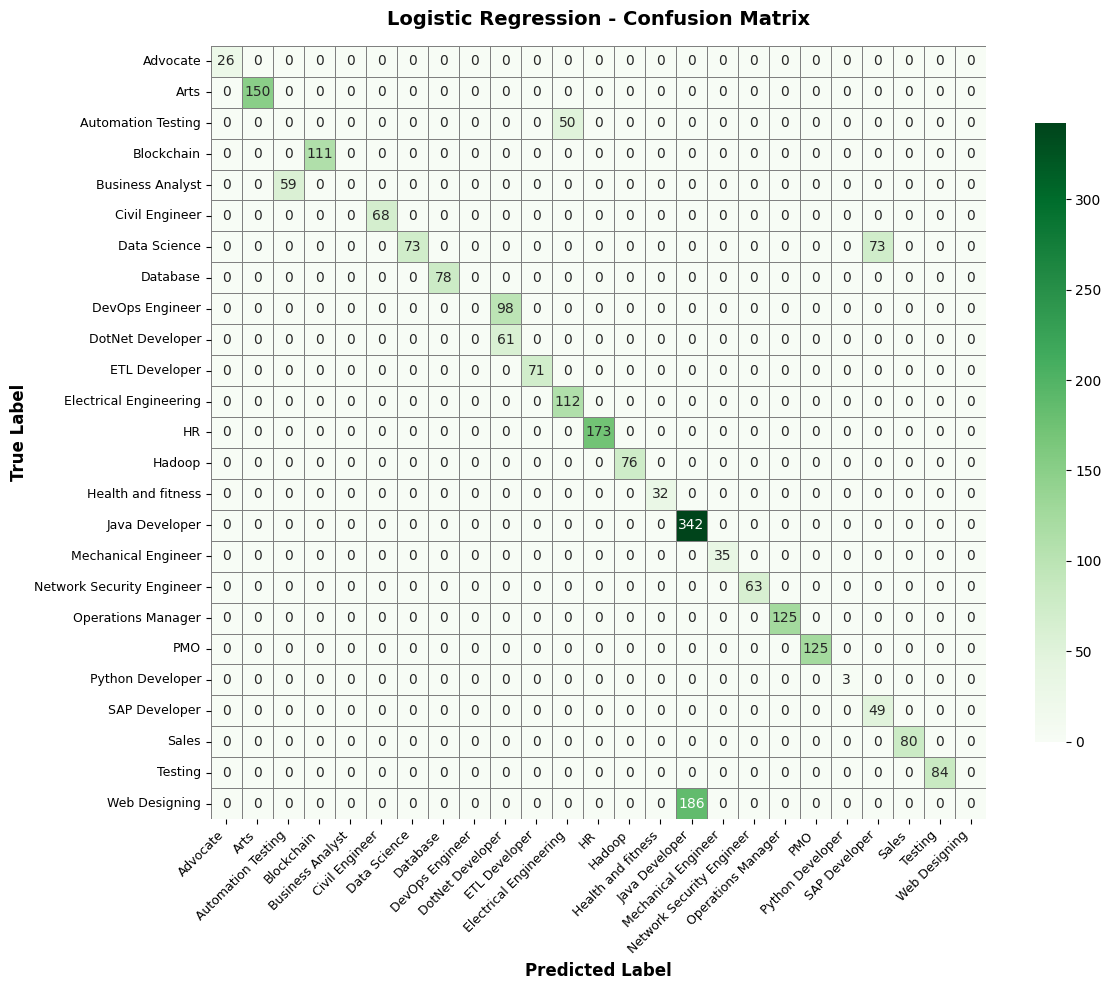

In [35]:
#confusion matrix heatmap
from sklearn.metrics import confusion_matrix

lr_cm=confusion_matrix(y_test,lr_test_pred)
fig,ax=plt.subplots(figsize=(12,10))
sns.heatmap(lr_cm,annot=True,fmt='d',cmap='Greens',
            xticklabels=le.classes_,yticklabels=le.classes_,ax=ax,
            linewidths=0.5,linecolor='gray',cbar_kws={'shrink':0.8})

ax.set_xlabel('Predicted Label',fontsize=12,fontweight='bold')
ax.set_ylabel('True Label',fontsize=12,fontweight='bold')
ax.set_title('Logistic Regression - Confusion Matrix',fontsize=14,fontweight='bold',pad=15)

plt.xticks(rotation=45,ha='right',fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Model Evaluation (Random Forest)

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

rf_model= RandomForestClassifier(n_estimators= 200, random_state= 42, n_jobs= -1)
rf_model.fit(X_train, y_train)
rf_train_pred= rf_model.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, rf_train_pred):.4f}")

Training Accuracy: 1.0000


In [38]:
rf_test_pred= rf_model.predict(X_test)
rf_accuracy= accuracy_score(y_test, rf_test_pred)

print(f"Random Forest - Test Results")
print("="*60)
print(f"Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print("\n"+"="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, rf_test_pred, target_names=le.classes_))

Random Forest - Test Results
Test Accuracy: 0.7507 (75.07%)

CLASSIFICATION REPORT
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       0.40      1.00      0.58        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00      0.82       112
                       HR       0.72      1.0

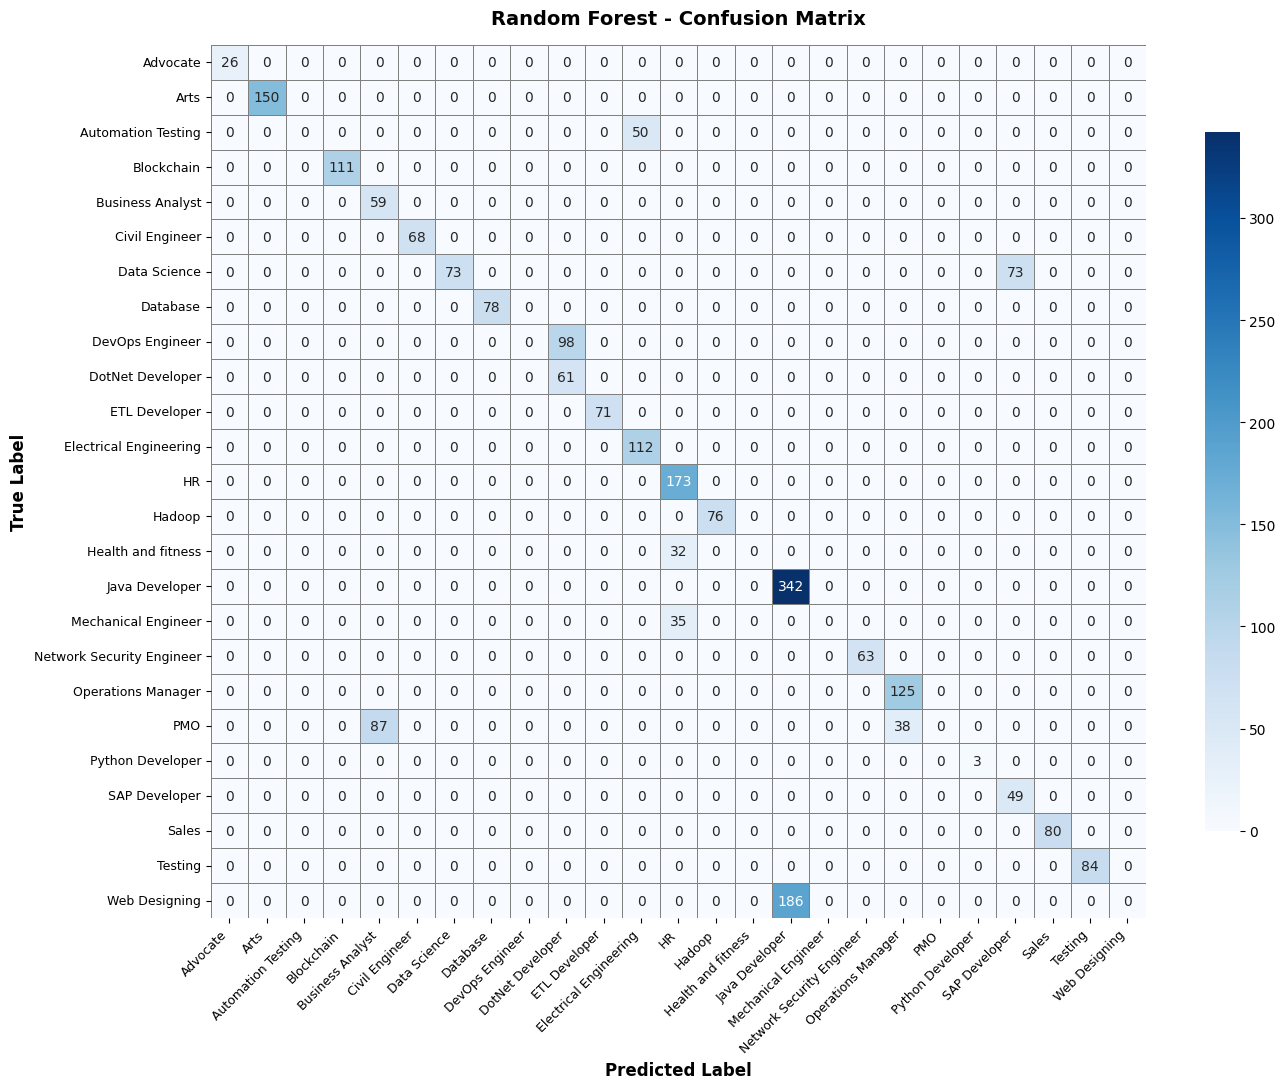

In [39]:
rf_cm= confusion_matrix(y_test, rf_test_pred)

fig, ax= plt.subplots(figsize=(14, 11))
sns.heatmap(rf_cm, annot= True, fmt= 'd', cmap= 'Blues',
            xticklabels= le.classes_, yticklabels= le.classes_,
            ax= ax, linewidths= 0.5, linecolor= 'gray', cbar_kws=
            {'shrink': 0.8})

ax.set_xlabel('Predicted Label', fontsize= 12, fontweight= 'bold')
ax.set_ylabel('True Label', fontsize= 12, fontweight= 'bold')

ax.set_title('Random Forest - Confusion Matrix',
             fontsize= 14, fontweight= 'bold', pad= 15)

plt.xticks(rotation= 45, ha= 'right', fontsize= 9)
plt.yticks(fontsize= 9)
plt.tight_layout()
plt.show()

# Model Evaluation (XGBoost)



In [40]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model= xgb.XGBClassifier(
    objective= 'multi:softmax',
    num_class= len(le.classes_),
    eval_metric= 'mlogloss',
    use_label_encoder= False,
    random_state= 42,
    n_jobs= -1
)

xgb_model.fit(X_train, y_train)

xgb_train_pred= xgb_model.predict(X_train)
xgb_test_pred= xgb_model.predict(X_test)

xgb_train_acc= accuracy_score(y_train, xgb_train_pred)
xgb_test_acc= accuracy_score(y_test, xgb_test_pred)

print(f"XGBoost - Traning accuracy: {xgb_train_acc:.4f}({xgb_train_acc*100: .2f}%)")
print(f"XGBoost - Test accuracy: {xgb_test_acc:.4f}({xgb_test_acc*100: .2f}%)")

print("\n"+"="*60)
print("CLASSIFICATION REPORT (XGBoost)")
print("="*60)
print(classification_report(y_test, xgb_test_pred, target_names=le.classes_))





XGBoost - Traning accuracy: 1.0000( 100.00%)
XGBoost - Test accuracy: 0.7108( 71.08%)

CLASSIFICATION REPORT (XGBoost)
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.98      1.00      0.99        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       1.00      0.98      0.99        59
           Civil Engineer       0.00      0.00      0.00        68
             Data Science       0.00      0.00      0.00       146
                 Database       0.30      1.00      0.46        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       0.00      0.00      0.00        71
   Electrical Engineering       1.00      1.00      1.00       112
         

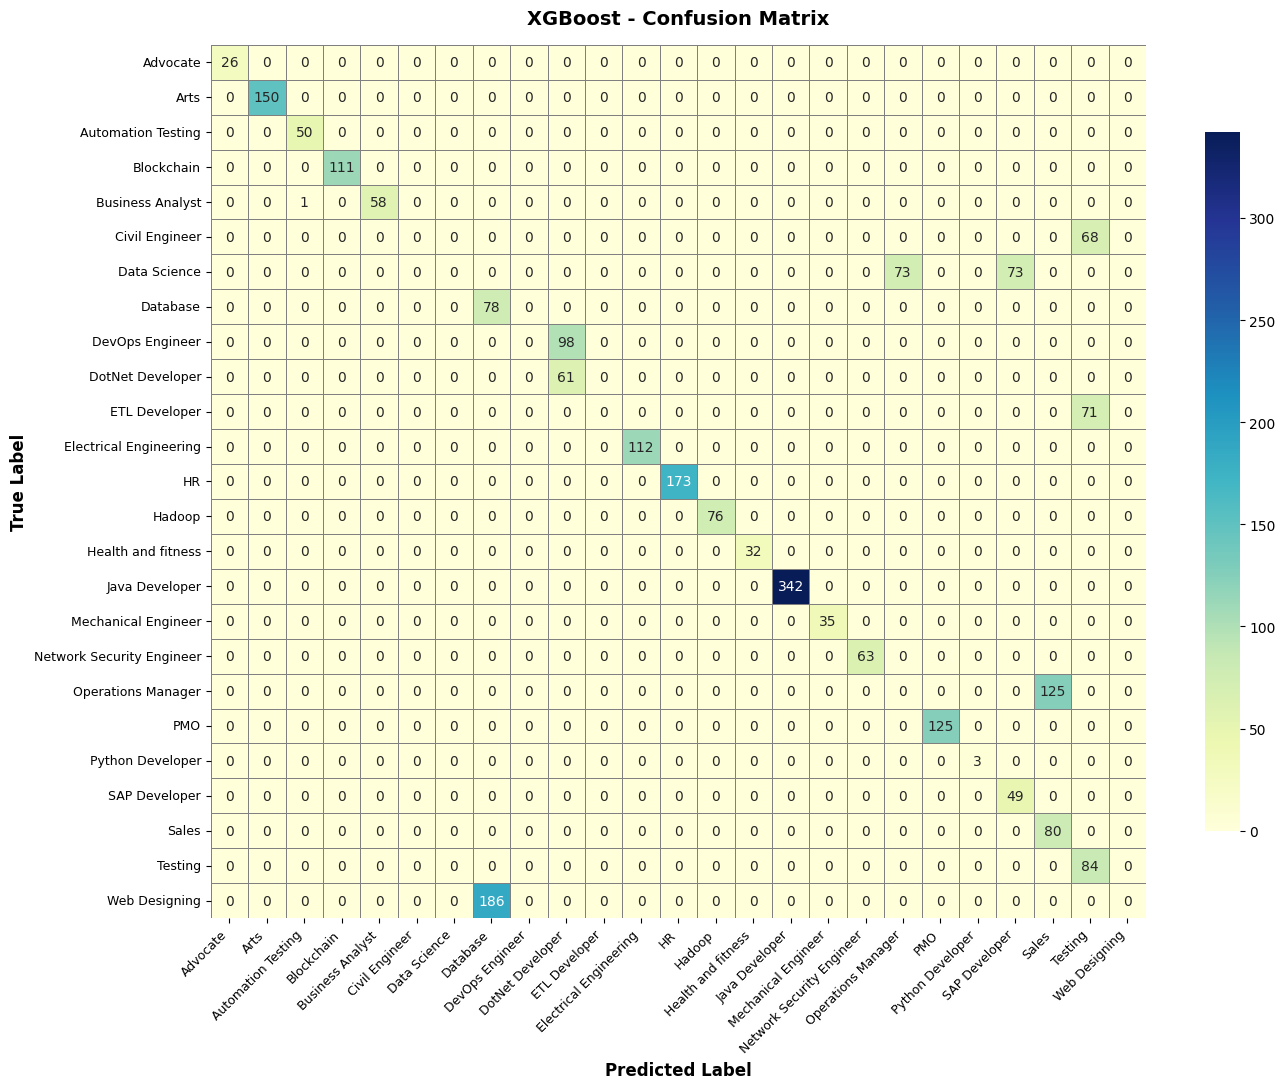

In [ ]:
xgb_cm= confusion_matrix(y_test, xgb_test_pred)
fig, ax= plt.subplots(figsize=(14, 11))

sns.heatmap(xgb_cm, annot= True, fmt='d', cmap='YlGnBu',
            xticklabels= le.classes_, yticklabels= le.classes_,
            ax= ax, linewidths= 0.5, linecolor= 'gray', cbar_kws=
            {'shrink': 0.8})

ax.set_xlabel('Predicted Label', fontsize= 12, fontweight= 'bold')
ax.set_ylabel('True Label', fontsize= 12, fontweight= 'bold')

ax.set_title('XGBoost - Confusion Matrix',
             fontsize= 14, fontweight= 'bold', pad= 15)

plt.xticks(rotation= 45, ha= 'right', fontsize= 9)
plt.yticks(fontsize= 9)
plt.tight_layout()
plt.show()


**Model Evaluation(Multinomial Naive Bayes)**

Naive Bayes - Training Accuracy : 1.0000 (100.00%)
Naive Bayes - Test Accuracy     : 0.6471 (64.71%)

CLASSIFICATION REPORT (Naive Bayes)
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       0.00      0.00      0.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       1.00      1.00      1.00        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.18      1.00      0.30        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00      0.82 

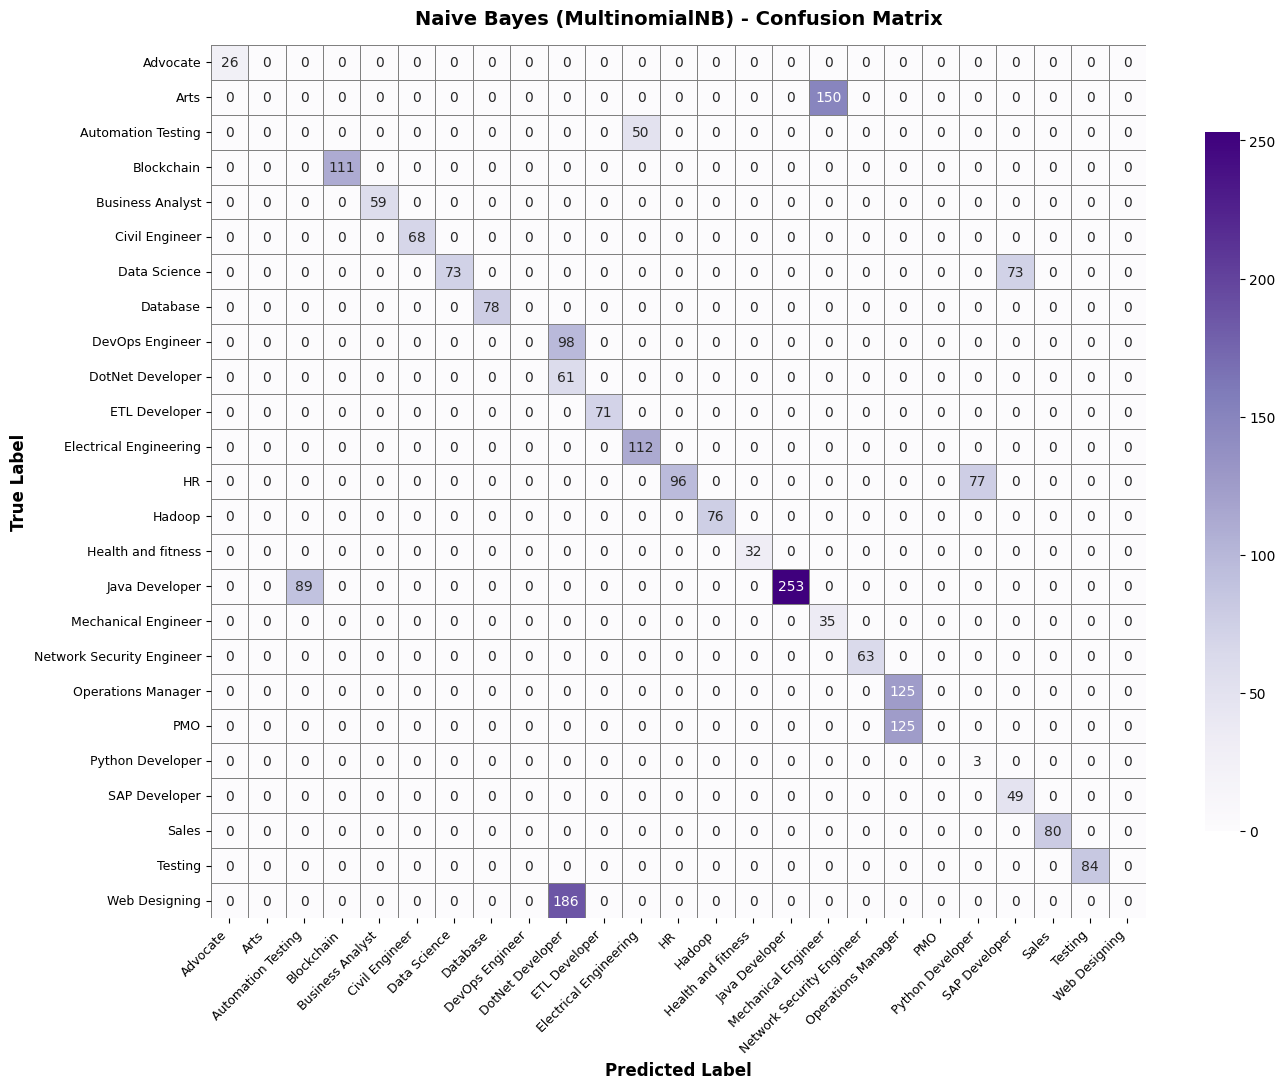

In [41]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_train_pred = nb_model.predict(X_train)
nb_test_pred = nb_model.predict(X_test)
nb_train_accuracy = accuracy_score(y_train, nb_train_pred)
nb_test_accuracy = accuracy_score(y_test, nb_test_pred)
print(f"Naive Bayes - Training Accuracy : {nb_train_accuracy:.4f} ({nb_train_accuracy*100:.2f}%)")
print(f"Naive Bayes - Test Accuracy     : {nb_test_accuracy:.4f} ({nb_test_accuracy*100:.2f}%)")
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Naive Bayes)")
print("="*60)
print(classification_report(y_test, nb_test_pred, target_names=le.classes_))
nb_cm = confusion_matrix(y_test, nb_test_pred)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Naive Bayes (MultinomialNB) - Confusion Matrix',
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**SVC(Support Vector Classifier)**


🟣 SVC (Support Vector Classifier) - Results
Training Accuracy : 1.0000 (100.00%)
Test Accuracy     : 0.7786 (77.86%)

CLASSIFICATION REPORT (SVC)
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       1.00      1.00      1.00        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00  

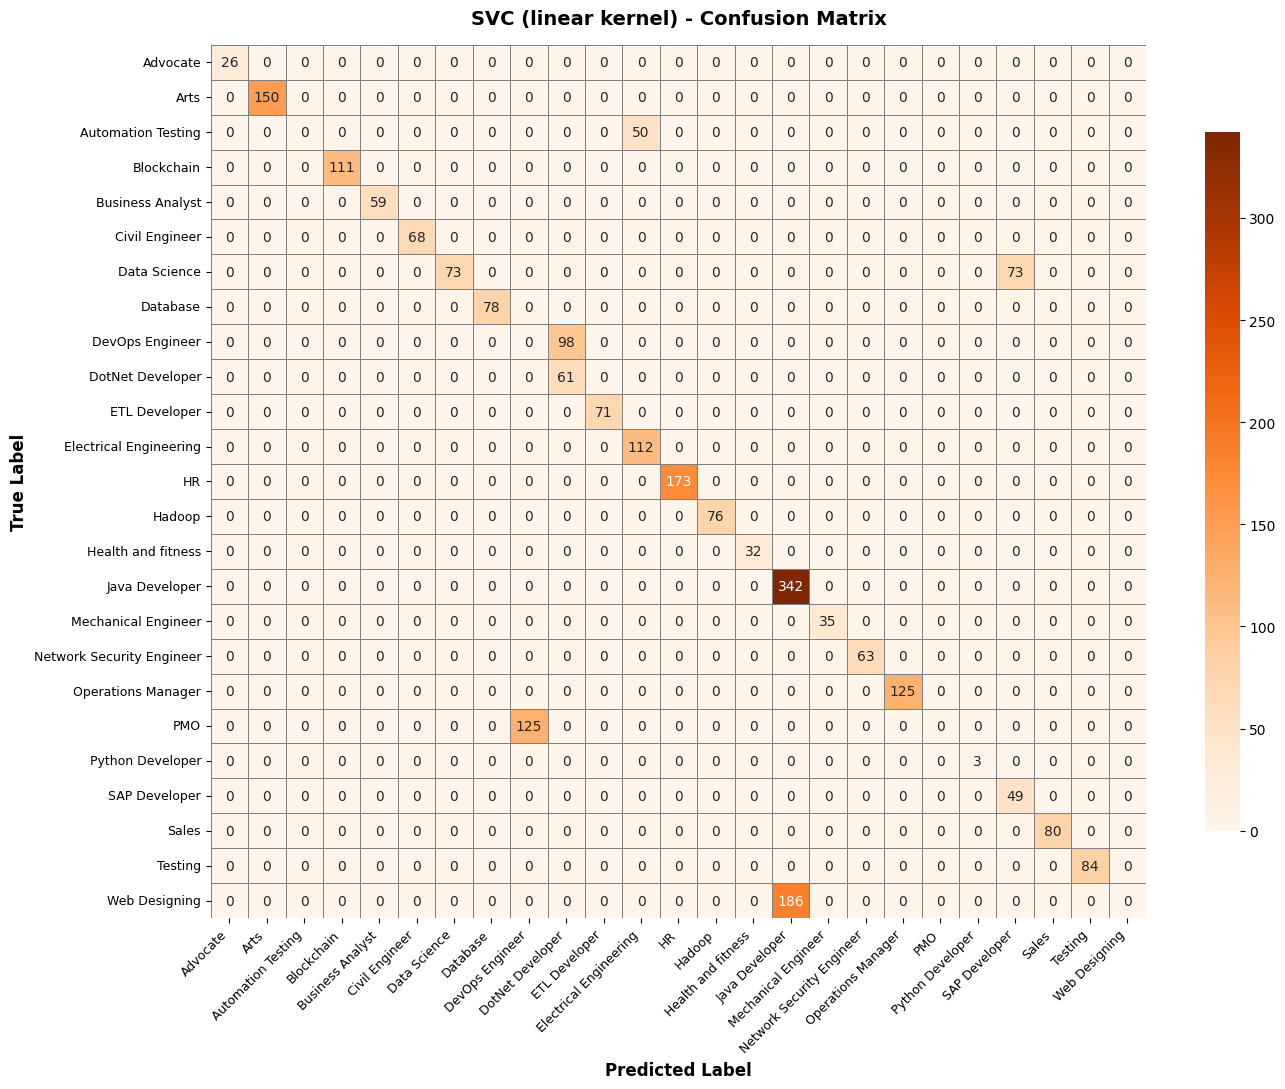

In [42]:
from sklearn.svm import SVC
svc_model = SVC(kernel='linear', random_state=42, C=1.0)
svc_model.fit(X_train, y_train)
svc_train_pred = svc_model.predict(X_train)
svc_test_pred = svc_model.predict(X_test)
svc_train_acc = accuracy_score(y_train, svc_train_pred)
svc_test_acc = accuracy_score(y_test, svc_test_pred)

print("\n" + "="*60)
print("🟣 SVC (Support Vector Classifier) - Results")
print("="*60)
print(f"Training Accuracy : {svc_train_acc:.4f} ({svc_train_acc*100:.2f}%)")
print(f"Test Accuracy     : {svc_test_acc:.4f} ({svc_test_acc*100:.2f}%)")

print("\n" + "="*60)
print("CLASSIFICATION REPORT (SVC)")
print("="*60)
print(classification_report(y_test, svc_test_pred, target_names=le.classes_))
svc_cm = confusion_matrix(y_test, svc_test_pred)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('SVC (linear kernel) - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**k-nearest neighbour**

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

KNN - Training Accuracy : 1.0000 (100.00%)
KNN - Test Accuracy     : 0.7366 (73.66%)

CLASSIFICATION REPORT (KNN)
                           precision    recall  f1-score   support

                 Advocate       1.00      0.35      0.51        26
                     Arts       0.00      0.00      0.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       0.00      0.00      0.00        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       1.00      1.00      1.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.69      1.00      0.82       112
              

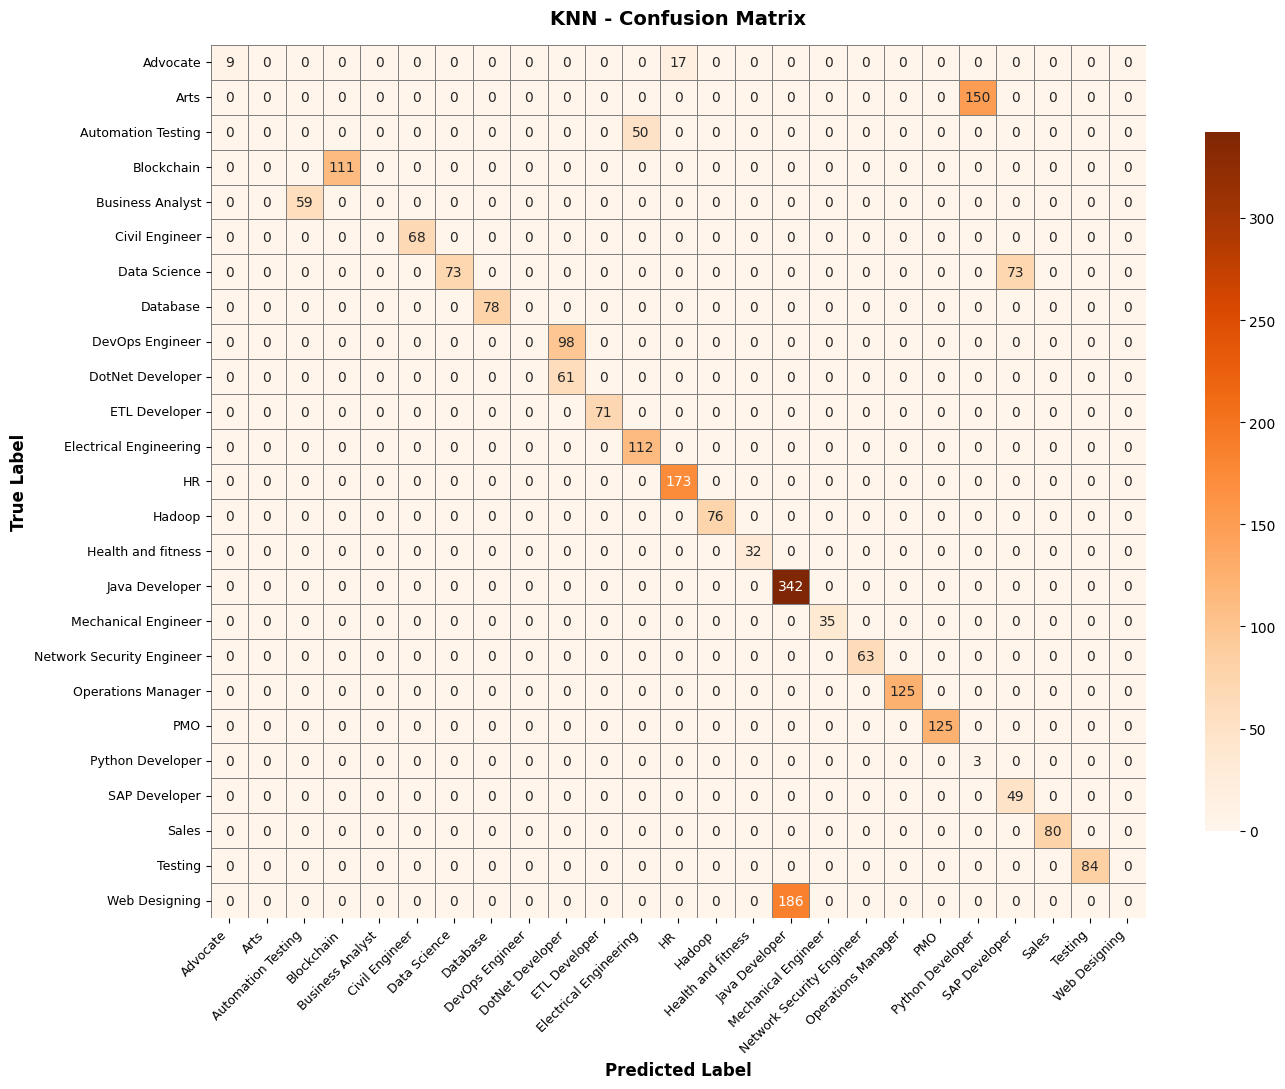

In [44]:
knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
knn_model.fit(X_train, y_train)

knn_train_pred = knn_model.predict(X_train)
knn_test_pred  = knn_model.predict(X_test)

knn_train_acc = accuracy_score(y_train, knn_train_pred)
knn_test_acc  = accuracy_score(y_test, knn_test_pred)

print(f"KNN - Training Accuracy : {knn_train_acc:.4f} ({knn_train_acc*100:.2f}%)")
print(f"KNN - Test Accuracy     : {knn_test_acc:.4f} ({knn_test_acc*100:.2f}%)")
print("\n" + "="*60)
print("CLASSIFICATION REPORT (KNN)")
print("="*60)
print(classification_report(y_test, knn_test_pred, target_names=le.classes_))

knn_cm = confusion_matrix(y_test, knn_test_pred)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('KNN - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Decision Tree**

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Decision Tree - Training Accuracy : 1.0000 (100.00%)
Decision Tree - Test Accuracy     : 0.5784 (57.84%)

CLASSIFICATION REPORT (Decision Tree)
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.46      1.00      0.63        50
               Blockchain       0.69      1.00      0.82       111
         Business Analyst       0.00      0.00      0.00        59
           Civil Engineer       0.00      0.00      0.00        68
             Data Science       0.00      0.00      0.00       146
                 Database       0.36      1.00      0.53        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        71
   Electrical Engineering       0.00      0.00     

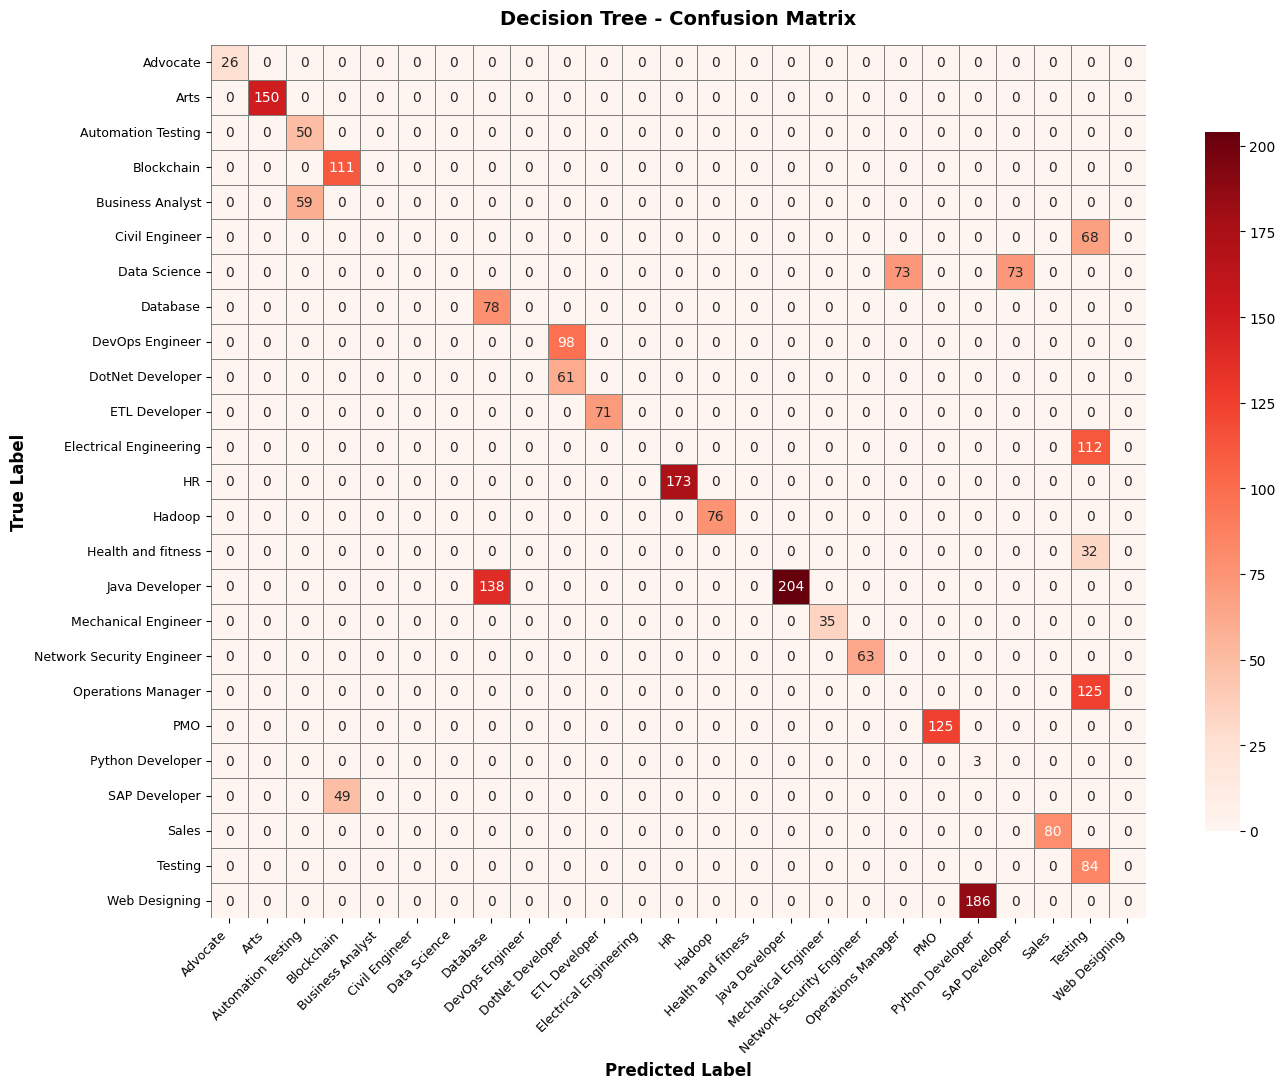

In [46]:
dt_model = DecisionTreeClassifier(max_depth=40, min_samples_split=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred  = dt_model.predict(X_test)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc  = accuracy_score(y_test, dt_test_pred)

print(f"Decision Tree - Training Accuracy : {dt_train_acc:.4f} ({dt_train_acc*100:.2f}%)")
print(f"Decision Tree - Test Accuracy     : {dt_test_acc:.4f} ({dt_test_acc*100:.2f}%)")
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Decision Tree)")
print("="*60)
print(classification_report(y_test, dt_test_pred, target_names=le.classes_))

dt_cm = confusion_matrix(y_test, dt_test_pred)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**AdaBoost**

In [47]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

AdaBoost - Training Accuracy : 0.1312 (13.12%)
AdaBoost - Test Accuracy     : 0.0012 (0.12%)

CLASSIFICATION REPORT (AdaBoost)
                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00        26
                     Arts       0.00      0.00      0.00       150
       Automation Testing       0.00      0.00      0.00        50
               Blockchain       0.00      0.00      0.00       111
         Business Analyst       0.00      0.00      0.00        59
           Civil Engineer       0.00      0.00      0.00        68
             Data Science       0.00      0.00      0.00       146
                 Database       0.00      0.00      0.00        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.00      0.00      0.00        61
            ETL Developer       0.00      0.00      0.00        71
   Electrical Engineering       0.00      0.00      0.00       112
 

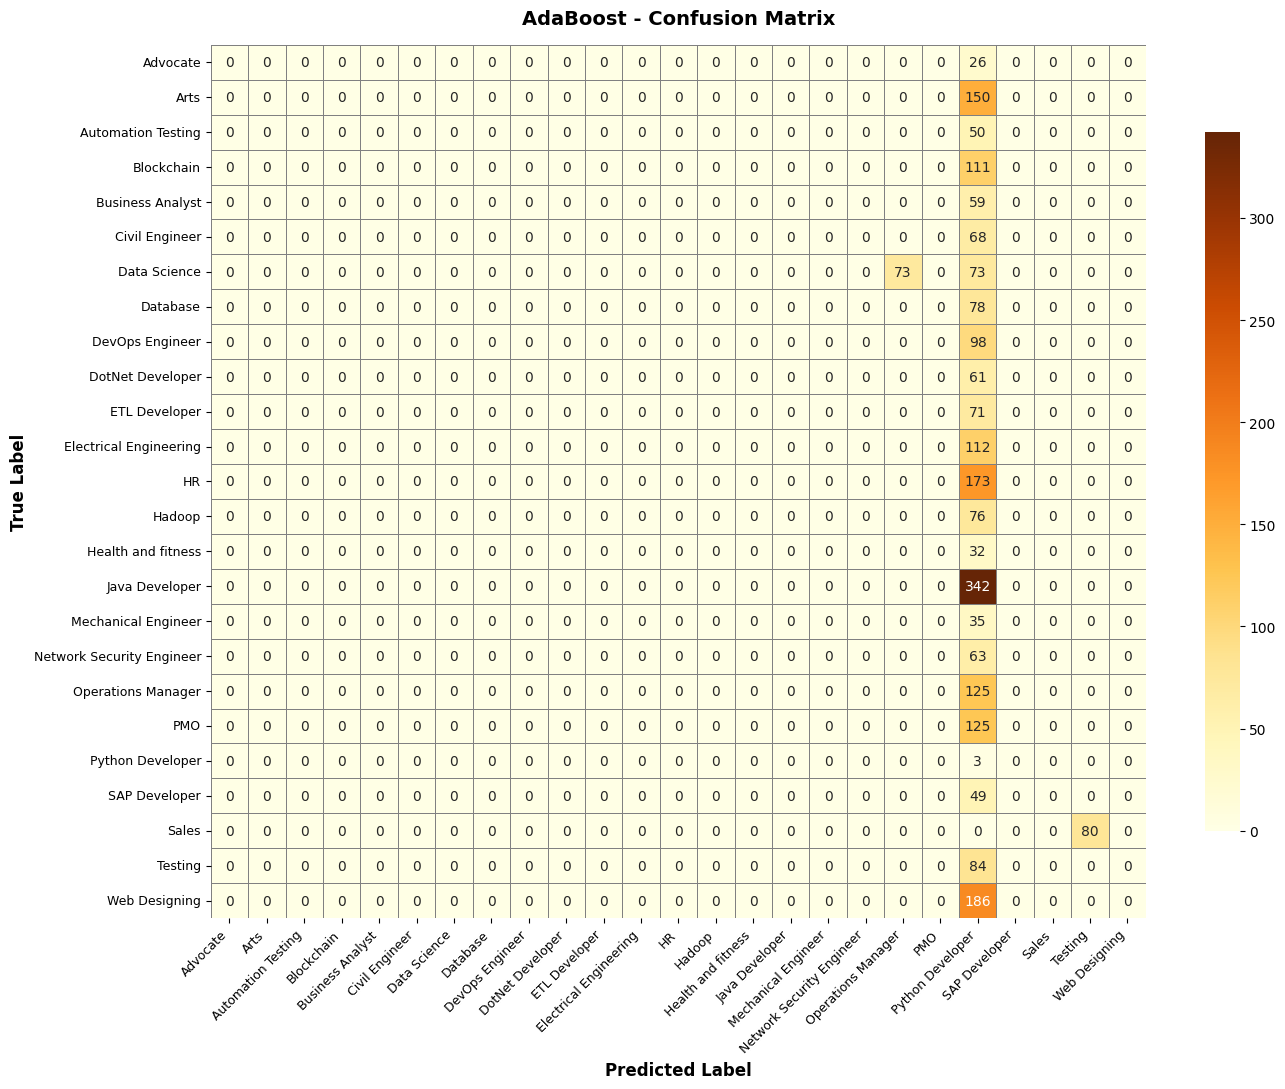

In [48]:
ada_model = AdaBoostClassifier(n_estimators=200, learning_rate=1.0, random_state=42)
ada_model.fit(X_train, y_train)

ada_train_pred = ada_model.predict(X_train)
ada_test_pred  = ada_model.predict(X_test)

ada_train_accuracy = accuracy_score(y_train, ada_train_pred)
ada_test_accuracy  = accuracy_score(y_test, ada_test_pred)

print(f"AdaBoost - Training Accuracy : {ada_train_accuracy:.4f} ({ada_train_accuracy*100:.2f}%)")
print(f"AdaBoost - Test Accuracy     : {ada_test_accuracy:.4f} ({ada_test_accuracy*100:.2f}%)")
print("\n" + "="*60)
print("CLASSIFICATION REPORT (AdaBoost)")
print("="*60)
print(classification_report(y_test, ada_test_pred, target_names=le.classes_))

ada_cm = confusion_matrix(y_test, ada_test_pred)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(ada_cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('AdaBoost - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Voting Classifier


  Voting Classifier (Ensemble) training....

📊 Voting Classifier Results:
   Training Accuracy : 1.0000 (100.00%)
   Test Accuracy     : 0.8510 (85.10%)

CLASSIFICATION REPORT (Voting Classifier)
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        26
                     Arts       1.00      1.00      1.00       150
       Automation Testing       0.98      1.00      0.99        50
               Blockchain       1.00      1.00      1.00       111
         Business Analyst       1.00      0.98      0.99        59
           Civil Engineer       1.00      1.00      1.00        68
             Data Science       1.00      0.50      0.67       146
                 Database       0.30      1.00      0.46        78
          DevOps Engineer       0.00      0.00      0.00        98
         DotNet Developer       0.38      1.00      0.55        61
            ETL Developer       1.00      1.00      1.00        7

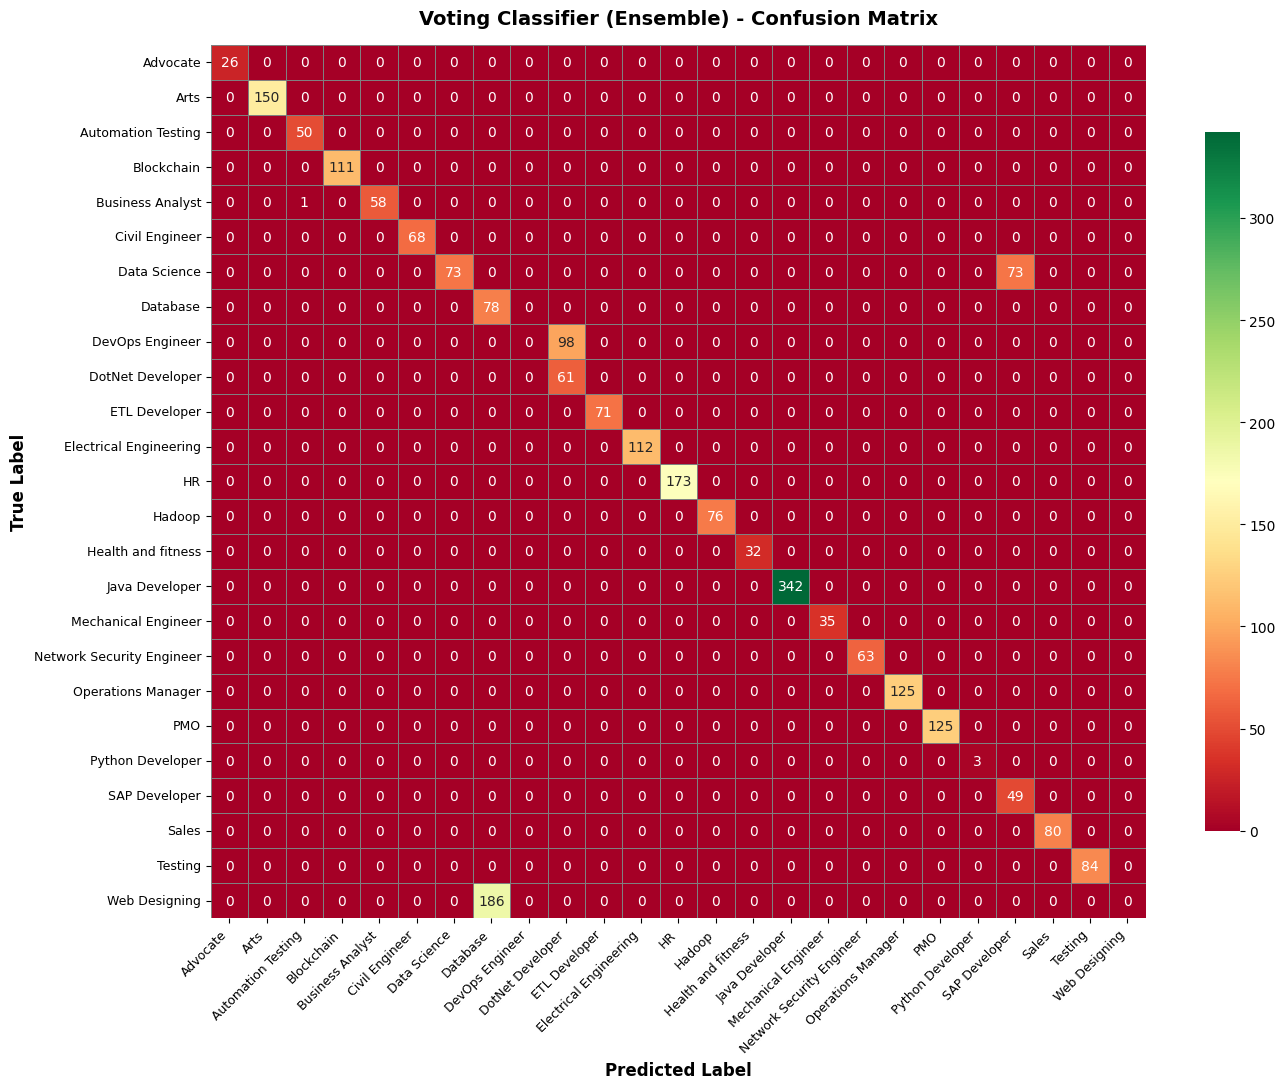


🏆 Best Model vs Voting Classifier - Comparison
Best Model (Logistic Regression): 0.8061 (80.61%)
Voting Classifier        : 0.8510 (85.10%)

🎉 Voting Classifier beat the best single model!
   Improvement: 4.49%


In [49]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

print("\n" + "="*60)
print("  Voting Classifier (Ensemble) training....")
print("="*60)

lr_model_ens  = LogisticRegression(max_iter=1000, random_state=42)
rf_model_ens  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
svc_model_ens = SVC(kernel='linear', random_state=42, probability=True)
xgb_model_ens = XGBClassifier(n_estimators=200, random_state=42, objective='multi:softmax', eval_metric='mlogloss')

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_model_ens),
        ('rf', rf_model_ens),
        ('svc', svc_model_ens),
        ('xgb', xgb_model_ens)
    ],
    voting='soft'  # soft voting = average each model's predicted probabilities
)

voting_clf.fit(X_train, y_train)

# Predict
voting_train_pred = voting_clf.predict(X_train)
voting_test_pred  = voting_clf.predict(X_test)

# Accuracy
voting_train_acc = accuracy_score(y_train, voting_train_pred)
voting_test_acc  = accuracy_score(y_test, voting_test_pred)

print(f"\n📊 Voting Classifier Results:")
print(f"   Training Accuracy : {voting_train_acc:.4f} ({voting_train_acc*100:.2f}%)")
print(f"   Test Accuracy     : {voting_test_acc:.4f} ({voting_test_acc*100:.2f}%)")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Voting Classifier)")
print("="*60)
print(classification_report(y_test, voting_test_pred, target_names=le.classes_))

# Confusion matrix
voting_cm = confusion_matrix(y_test, voting_test_pred)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Voting Classifier (Ensemble) - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# Best Model vs Voting Classifier comparison
# ============================================
print("\n" + "="*60)
print("🏆 Best Model vs Voting Classifier - Comparison")
print("="*60)

# Initialize best_model_name, best_acc, and best_model from previously trained single models
# This ensures these variables are defined for the comparison.
# We are comparing against the best individual model prior to the ensemble.
model_results = {
    'Logistic Regression': {'accuracy': lr_accuracy, 'model': lr_model},
    'Random Forest': {'accuracy': rf_accuracy, 'model': rf_model},
    'Multinomial Naive Bayes': {'accuracy': nb_test_accuracy, 'model': nb_model},
    'K-Nearest Neighbors': {'accuracy': knn_test_acc, 'model': knn_model},
    'Decision Tree': {'accuracy': dt_test_acc, 'model': dt_model},
    'SVC': {'accuracy': svc_test_acc, 'model': svc_model},
    'XGBoost': {'accuracy': xgb_test_acc, 'model': xgb_model},
    'AdaBoost': {'accuracy': ada_test_accuracy, 'model': ada_model},
}

best_acc_individual = 0.0
best_model_name_individual = "None"
best_model_object_individual = None

for name, data in model_results.items():
    if data['accuracy'] > best_acc_individual:
        best_acc_individual = data['accuracy']
        best_model_name_individual = name
        best_model_object_individual = data['model']

# Use these initial values for comparison
best_model_name = best_model_name_individual
best_acc = best_acc_individual
best_model = best_model_object_individual

print(f"Best Model ({best_model_name}): {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"Voting Classifier        : {voting_test_acc:.4f} ({voting_test_acc*100:.2f}%)")

if voting_test_acc > best_acc:
    print("\n🎉 Voting Classifier beat the best single model!")
    print(f"   Improvement: {(voting_test_acc - best_acc)*100:.2f}%")
    best_model_name = "Voting Classifier"
    best_model = voting_clf
    best_acc = voting_test_acc
else:
    print(f"\n💪 Best Model ({best_model_name}) is still best")
    print(f"   Voting Classifier lost by {(best_acc - voting_test_acc)*100:.2f}%")

BEST MODEL SELECTION - COMPARISON

In [51]:
lr_train_acc  = accuracy_score(y_train, lr_model.predict(X_train))
rf_train_acc  = accuracy_score(y_train, rf_model.predict(X_train))
knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))
dt_train_acc  = accuracy_score(y_train, dt_model.predict(X_train))
svc_train_acc = accuracy_score(y_train, svc_model.predict(X_train))

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Multinomial Naive Bayes',
              'K-Nearest Neighbors', 'Decision Tree', 'SVC',
              'XGBoost', 'Voting Ensemble', 'AdaBoost'],
    'Training Accuracy': [lr_train_acc, rf_train_acc, nb_train_accuracy,
                           knn_train_acc, dt_train_acc, svc_train_acc,
                           xgb_train_acc, voting_train_acc, ada_train_accuracy],
    'Test Accuracy': [lr_accuracy, rf_accuracy, nb_test_accuracy,
                       knn_test_acc, dt_test_acc, svc_test_acc,
                       xgb_test_acc, voting_test_acc, ada_test_accuracy],
})

results_df['Overfitting Gap'] = results_df['Training Accuracy'] - results_df['Test Accuracy']

results_df['Training Accuracy'] = results_df['Training Accuracy'].round(4)
results_df['Test Accuracy'] = results_df['Test Accuracy'].round(4)
results_df['Overfitting Gap'] = results_df['Overfitting Gap'].round(4)

results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("🏆 MODEL COMPARISON SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

best_idx = results_df['Test Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_acc = results_df.loc[best_idx, 'Test Accuracy']

print(f"\n🎯 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

best_model = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Multinomial Naive Bayes': nb_model,
    'K-Nearest Neighbors': knn_model,
    'Decision Tree': dt_model,
    'SVC': svc_model,
    'XGBoost': xgb_model,
    'Voting Ensemble': voting_clf,
    'AdaBoost': ada_model,
}[best_model_name]

🏆 MODEL COMPARISON SUMMARY
                  Model  Training Accuracy  Test Accuracy  Overfitting Gap
        Voting Ensemble             1.0000         0.8510           0.1490
    Logistic Regression             1.0000         0.8061           0.1939
                    SVC             1.0000         0.7786           0.2214
          Random Forest             1.0000         0.7507           0.2493
    K-Nearest Neighbors             1.0000         0.7366           0.2634
                XGBoost             1.0000         0.7108           0.2892
Multinomial Naive Bayes             1.0000         0.6471           0.3529
          Decision Tree             1.0000         0.5784           0.4216
               AdaBoost             0.1312         0.0012           0.1300

🎯 BEST MODEL: Voting Ensemble
   Test Accuracy: 0.8510 (85.10%)


VISUAL COMPARISON - ACCURACY BAR CHART

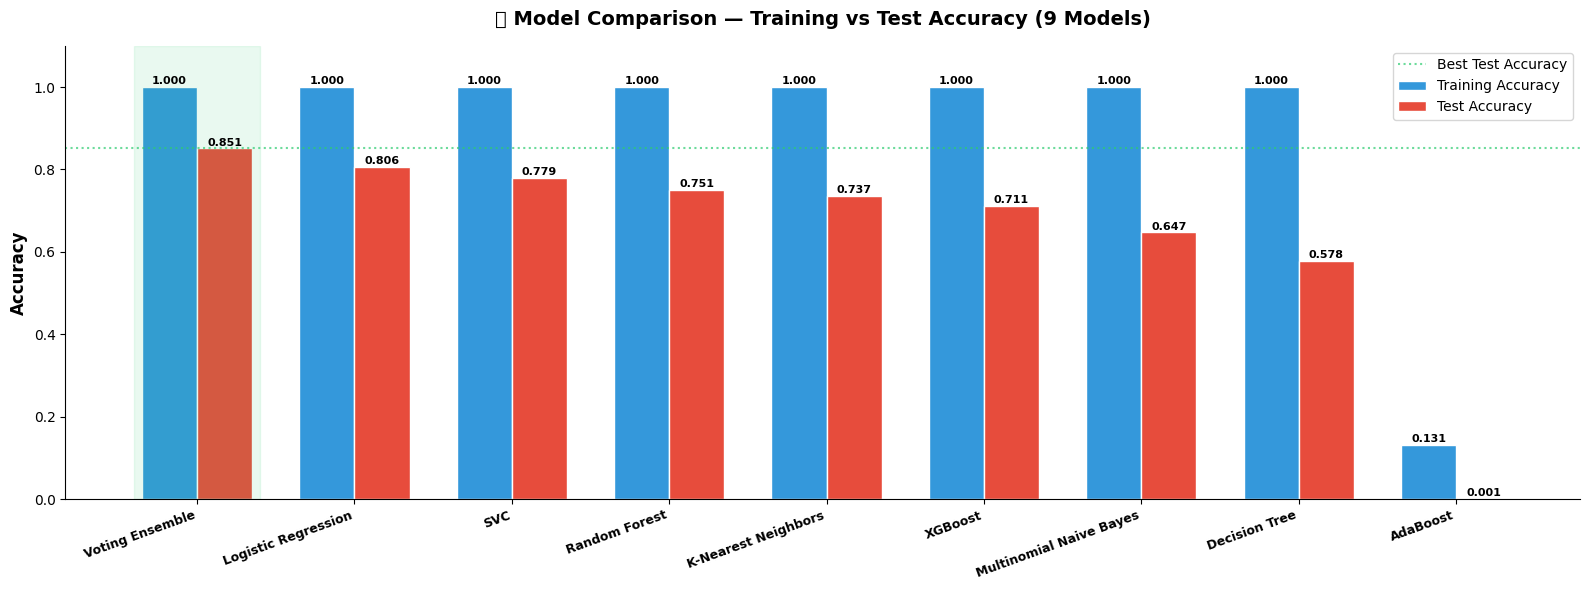

In [52]:
fig, ax = plt.subplots(figsize=(16, 6))

x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['Training Accuracy'],
               width, label='Training Accuracy', color='#3498db', edgecolor='white', linewidth=1)

bars2 = ax.bar([i + width/2 for i in x], results_df['Test Accuracy'],
               width, label='Test Accuracy', color='#e74c3c', edgecolor='white', linewidth=1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

best_pos = results_df.index.get_loc(best_idx)
ax.axvspan(best_pos - 0.4, best_pos + 0.4, alpha=0.1, color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=9, fontweight='bold', rotation=20, ha='right')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('🏆 Model Comparison — Training vs Test Accuracy (9 Models)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(results_df['Training Accuracy']) + 0.1)
ax.axhline(y=best_acc, color='#2ecc71', linestyle=':', alpha=0.7, label='Best Test Accuracy')
ax.legend(fontsize=10, loc='upper right')
sns.despine()

plt.tight_layout()
plt.show()

# Prediction system


In [53]:
def predict_resume_category(resume_text, model=best_model, vectorizer=tfidf, label_encoder=le):
    '''
    Predict the job category for a given resume text.

    Args:
        resume_text (str): Raw resume text to classify
        model: Trained ML model (default: best_model)
        vectorizer: Fitted TF-IDF vectorizer (default: tfidf)
        label_encoder: Fitted LabelEncoder (default: le)

    Returns:
        tuple: (predicted_category, top_3_predictions_with_probabilities)
    '''
    cleaned = cleanResume(resume_text)
    features = vectorizer.transform([cleaned])

    prediction = model.predict(features)[0]

    probabilities = model.predict_proba(features)[0]

    top_3_idx = np.argsort(probabilities)[-3:][::-1]
    top_3_predictions = [
        (label_encoder.classes_[i], probabilities[i])
        for i in top_3_idx
    ]

    predicted_category = label_encoder.classes_[prediction]
    return predicted_category, top_3_predictions


print("   Prediction function defined successfully!")
print(f"   Accepts: Raw resume text (string)")
print(f"   Returns: (Predicted job role, Top 3 predictions with confidence scores)")

   Prediction function defined successfully!
   Accepts: Raw resume text (string)
   Returns: (Predicted job role, Top 3 predictions with confidence scores)


In [54]:
# --- Sample Resume 1: Data Scientist ---
sample_resume_1 = '''
Dr. Sarah Chen
Email: sarah.chen@datascience.com | Phone: +1-555-123-4567

PROFESSIONAL SUMMARY:
PhD in Statistics with 8 years of experience in machine learning, deep learning, and predictive modeling.
Expert in Python, TensorFlow, and scikit-learn. Published 15+ research papers in top ML conferences.

SKILLS:
Python, R, TensorFlow, PyTorch, SQL, Pandas, NumPy, Scikit-learn, Tableau, Jupyter,
Natural Language Processing, Computer Vision, Statistical Modeling, A/B Testing

EXPERIENCE:
Senior Data Scientist at Google Brain (2020-Present)
- Led a team of 5 researchers developing state-of-the-art NLP models
- Improved search ranking algorithm by 25% using transformer architectures
- Published 8 papers at NeurIPS, ICML, and ACL

Data Scientist at Netflix (2017-2020)
- Built recommendation system serving 200M+ users
- Developed computer vision models for content understanding
- Reduced churn by 15% through predictive analytics
'''

prediction_1, top3_1 = predict_resume_category(sample_resume_1)

print(" SAMPLE PREDICTION #1")
print("=" * 60)
print(f" Resume: Data Scientist Profile (Dr. Sarah Chen)")
print(f" Predicted Role: {prediction_1}")
print(f"\n Top 3 Predictions:")
for rank, (role, prob) in enumerate(top3_1, 1):
    bar = '█' * int(prob * 50)
    print(f"   {rank}. {role:<35} {prob:.4f} {bar}")

 SAMPLE PREDICTION #1
 Resume: Data Scientist Profile (Dr. Sarah Chen)
 Predicted Role: Data Science

 Top 3 Predictions:
   1. Data Science                        0.6374 ███████████████████████████████
   2. Python Developer                    0.0427 ██
   3. Arts                                0.0317 █


In [55]:
# --- Sample Resume 2: DevOps Engineer ---
sample_resume_2 = '''
Mike Rodriguez
Email: mike.devops@cloudops.io | Phone: +1-555-987-6543

PROFESSIONAL SUMMARY:
DevOps Engineer with 6 years of experience in cloud infrastructure, CI/CD pipelines,
and containerization. AWS certified solutions architect.

SKILLS:
Docker, Kubernetes, Jenkins, AWS (EC2, S3, Lambda, ECS), Terraform, Ansible,
CI/CD, Linux, Bash, Python, Prometheus, Grafana, CloudFormation

EXPERIENCE:
Senior DevOps Engineer at Amazon (2021-Present)
- Managed 500+ microservices using Kubernetes across 3 AWS regions
- Reduced deployment time by 70% using automated CI/CD with Jenkins
- Implemented infrastructure as code with Terraform managing 200+ resources

DevOps Engineer at Spotify (2018-2021)
- Built zero-downtime deployment pipelines for 50+ services
- Set up monitoring and alerting using Prometheus and Grafana
- Reduced cloud costs by 30% through resource optimization
'''

prediction_2, top3_2 = predict_resume_category(sample_resume_2)

print("🧪 SAMPLE PREDICTION #2")
print("=" * 60)
print(f"📄 Resume: DevOps Engineer Profile (Mike Rodriguez)")
print(f"🎯 Predicted Role: {prediction_2}")
print(f"\n📊 Top 3 Predictions:")
for rank, (role, prob) in enumerate(top3_2, 1):
    bar = '█' * int(prob * 50)
    print(f"   {rank}. {role:<35} {prob:.4f} {bar}")

🧪 SAMPLE PREDICTION #2
📄 Resume: DevOps Engineer Profile (Mike Rodriguez)
🎯 Predicted Role: DevOps Engineer

📊 Top 3 Predictions:
   1. DevOps Engineer                     0.5981 █████████████████████████████
   2. HR                                  0.0418 ██
   3. Testing                             0.0391 █


In [56]:
# --- Sample Resume 3: Frontend Developer ---
sample_resume_3 = '''
Emily Watson
Email: emily.frontend@gmail.com | Phone: +1-555-456-7890

PROFESSIONAL SUMMARY:
Creative Frontend Developer with 5 years of experience building responsive,
accessible web applications. Passionate about user experience and performance optimization.

SKILLS:
React, Vue.js, TypeScript, JavaScript, HTML5, CSS3, SASS, Tailwind CSS,
Redux, Webpack, Next.js, Jest, React Testing Library, Figma, Storybook

EXPERIENCE:
Frontend Developer at Airbnb (2021-Present)
- Built and maintained the booking experience serving 50M+ monthly visitors
- Improved Core Web Vitals scores by 40% through code splitting and lazy loading
- Developed a reusable component library used across 15 teams

Junior Frontend Developer at Shopify (2019-2021)
- Created responsive themes for 100+ merchant stores
- Implemented accessibility features achieving WCAG 2.1 AA compliance
- Collaborated with designers using Figma to pixel-perfect implementations
'''

prediction_3, top3_3 = predict_resume_category(sample_resume_3)

print("🧪 SAMPLE PREDICTION #3")
print("=" * 60)
print(f"📄 Resume: Frontend Developer Profile (Emily Watson)")
print(f"🎯 Predicted Role: {prediction_3}")
print(f"\n📊 Top 3 Predictions:")
for rank, (role, prob) in enumerate(top3_3, 1):
    bar = '█' * int(prob * 50)
    print(f"   {rank}. {role:<35} {prob:.4f} {bar}")

# --- Overall prediction summary ---
print("\n" + "=" * 60)
print("🎯 PREDICTION SUMMARY")
print("=" * 60)
print(f"   Resume 1 (Data Scientist)   → Predicted: {prediction_1} {'✅' if prediction_1 == 'Data Scientist' else '⚠️'}")
print(f"   Resume 2 (DevOps Engineer)  → Predicted: {prediction_2} {'✅' if prediction_2 == 'DevOps Engineer' else '⚠️'}")
print(f"   Resume 3 (Frontend Dev)     → Predicted: {prediction_3} {'✅' if prediction_3 == 'Frontend Developer' else '⚠️'}")

🧪 SAMPLE PREDICTION #3
📄 Resume: Frontend Developer Profile (Emily Watson)
🎯 Predicted Role: Java Developer

📊 Top 3 Predictions:
   1. Java Developer                      0.1475 ███████
   2. HR                                  0.0647 ███
   3. Web Designing                       0.0588 ██

🎯 PREDICTION SUMMARY
   Resume 1 (Data Scientist)   → Predicted: Data Science ⚠️
   Resume 2 (DevOps Engineer)  → Predicted: DevOps Engineer ✅
   Resume 3 (Frontend Dev)     → Predicted: Java Developer ⚠️


**ATS scoring and feedback**

In [57]:
from sklearn.metrics.pairwise import cosine_similarity
import re
import numpy as np

print("\n" + "="*60)
print("📄 ATS Scoring & Feedback System (Demo)")
print("="*60)

# 1. Pre-defined Skills Database
SKILLS_DB = [
    'python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'php', 'ruby', 'go', 'rust',
    'sql', 'mysql', 'postgresql', 'mongodb', 'oracle', 'nosql', 'sql server',
    'html', 'css', 'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'spring boot',
    'asp.net', 'rails', 'laravel',
    'machine learning', 'deep learning', 'nlp', 'computer vision', 'data science', 'data analysis',
    'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'matplotlib', 'seaborn',
    'tableau', 'power bi', 'excel', 'statistics',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'linux', 'bash', 'terraform',
    'agile', 'scrum', 'project management', 'leadership', 'team management', 'communication'
]

def extract_skills_rule_based(text):
    """Extract skills from text using a predefined skill list"""
    if not text:
        return []
    text_lower = text.lower()
    found = []
    for skill in SKILLS_DB:
        if skill in text_lower:
            found.append(skill)
    return list(set(found))

def clean_text_for_ats(text):
    """Clean text for ATS processing"""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def calculate_ats_score(resume_text, job_description):

    clean_resume = clean_text_for_ats(resume_text)
    clean_job = clean_text_for_ats(job_description)


    try:
        resume_vec = tfidf.transform([clean_resume])
        job_vec = tfidf.transform([clean_job])

        similarity = cosine_similarity(resume_vec, job_vec)[0][0] * 100
    except:

        similarity = 50.0


    resume_skills = extract_skills_rule_based(clean_resume)
    job_skills = extract_skills_rule_based(clean_job)

    common_skills = set(resume_skills).intersection(set(job_skills))
    missing_skills = set(job_skills) - set(resume_skills)

    if len(job_skills) > 0:
        skill_match_pct = (len(common_skills) / len(job_skills)) * 100
    else:
        skill_match_pct = 0.0

    overall_score = (similarity * 0.6) + (skill_match_pct * 0.4)
    overall_score = min(100, overall_score)

    return {
        'overall_score': round(overall_score, 2),
        'similarity_score': round(similarity, 2),
        'skill_match_percentage': round(skill_match_pct, 2),
        'matched_skills': list(common_skills),
        'missing_skills': list(missing_skills)[:10],  # Top 10 missing
        'total_job_skills': len(job_skills)
    }

def generate_feedback(ats_result, resume_text, job_description):
    """
    Generate user feedback based on ATS results
    """
    feedback = []
    score = ats_result['overall_score']

    # 1. Overall rating
    if score >= 80:
        feedback.append("🌟 **Excellent!** Your resume is almost perfect for this job.")
    elif score >= 60:
        feedback.append("✅ **Good!** Your resume is great, but some improvements can make it even better.")
    elif score >= 40:
        feedback.append("⚠️ **Average!** Your resume has room for improvement. Follow the suggestions below.")
    else:
        feedback.append("❌ **Needs Improvement!** Your resume doesn't match well with this job. Consider adding relevant skills or experience.")

    if ats_result['missing_skills']:
        missing = ', '.join(ats_result['missing_skills'][:5])
        feedback.append(f"📝 **Missing Skills:** `{missing}` - Try adding these skills to your resume.")
    else:
        feedback.append("🎯 **Great!** All important skills from the job description are present in your resume.")

    if ats_result['matched_skills']:
        matched = ', '.join(ats_result['matched_skills'][:5])
        feedback.append(f"✅ **Matching Skills:** `{matched}` - These skills are giving you an edge.")


    if ats_result['skill_match_percentage'] < 50:
        feedback.append("💡 **Tip:** Add important keywords (skills, tools, technologies) from the job description to your 'Skills' or 'Experience' section.")

    if ats_result['similarity_score'] < 50:
        feedback.append("📄 **Tip:** Align your resume language with the job description. Using similar terminology improves the score.")

    return feedback



sample_resume = """
I am a Data Scientist with 5 years of experience in Python, Machine Learning, and Deep Learning.
I have worked extensively with TensorFlow, PyTorch, and Scikit-learn.
My expertise includes NLP, Computer Vision, and Data Analysis using Pandas and NumPy.
I have deployed models on AWS and Docker.
"""

sample_job_description = """
Looking for a Senior Data Scientist with strong Python skills.
Must have experience in Machine Learning, Deep Learning, and NLP.
Experience with TensorFlow, PyTorch, and cloud platforms like AWS is a plus.
Should be proficient in Data Analysis and have knowledge of Docker.
"""

print("\n📌 Testing ATS score with sample resume and job description...")
print("-" * 60)

ats_result = calculate_ats_score(sample_resume, sample_job_description)

print(f"\n📊 **ATS Score Report:**")
print(f"   🎯 Overall ATS Score : {ats_result['overall_score']} / 100")
print(f"   📈 Similarity Score  : {ats_result['similarity_score']} / 100")
print(f"   🔑 Skill Match      : {ats_result['skill_match_percentage']}% ({len(ats_result['matched_skills'])}/{ats_result['total_job_skills']} skills matched)")
print(f"   ✅ Matched Skills   : {', '.join(ats_result['matched_skills']) if ats_result['matched_skills'] else 'None matched'}")
print(f"   ❌ Missing Skills   : {', '.join(ats_result['missing_skills']) if ats_result['missing_skills'] else 'No missing skills! 🎉'}")


feedback_list = generate_feedback(ats_result, sample_resume, sample_job_description)

print("\n💬 **Feedback & Suggestions:**")
for line in feedback_list:
    print(f"   {line}")

print("\n" + "="*60)
print("✅ ATS Scoring Demo Completed!")
print("="*60)


📄 ATS Scoring & Feedback System (Demo)

📌 Testing ATS score with sample resume and job description...
------------------------------------------------------------

📊 **ATS Score Report:**
   🎯 Overall ATS Score : 72.87 / 100
   📈 Similarity Score  : 54.79 / 100
   🔑 Skill Match      : 100.0% (9/9 skills matched)
   ✅ Matched Skills   : docker, data analysis, nlp, aws, deep learning, python, tensorflow, machine learning, pytorch
   ❌ Missing Skills   : No missing skills! 🎉

💬 **Feedback & Suggestions:**
   ✅ **Good!** Your resume is great, but some improvements can make it even better.
   🎯 **Great!** All important skills from the job description are present in your resume.
   ✅ **Matching Skills:** `docker, data analysis, nlp, aws, deep learning` - These skills are giving you an edge.

✅ ATS Scoring Demo Completed!


In [58]:
# ============================================
# 1 & 2. Consolidated Skills DB + Synonym/Fuzzy Skill Matching
# ============================================
import difflib
import re

# Single source of truth for the skill list (used everywhere below)
SKILLS_DB = [
    'python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'php', 'ruby', 'go', 'rust',
    'sql', 'mysql', 'postgresql', 'mongodb', 'oracle', 'nosql', 'sql server',
    'html', 'css', 'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'spring boot',
    'asp.net', 'rails', 'laravel', 'bootstrap', 'jquery',
    'machine learning', 'deep learning', 'nlp', 'computer vision', 'data science', 'data analysis',
    'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'keras', 'matplotlib', 'seaborn',
    'tableau', 'power bi', 'excel', 'data visualization', 'statistics',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'linux', 'bash', 'terraform',
    'ansible', 'prometheus', 'grafana', 'ci/cd', 'devops',
    'agile', 'scrum', 'project management', 'leadership', 'team management', 'communication',
    'problem solving', 'critical thinking', 'time management', 'collaboration', 'decision making',
    'cybersecurity', 'network security', 'penetration testing', 'ethical hacking', 'security',
    'sap', 'salesforce', 'erp', 'blockchain', 'iot', 'robotics', 'automation', 'testing', 'qa'
]

# Common abbreviations / synonyms -> canonical skill name in SKILLS_DB
SKILL_SYNONYMS = {
    'ml': 'machine learning',
    'dl': 'deep learning',
    'js': 'javascript',
    'ts': 'typescript',
    'k8s': 'kubernetes',
    'postgres': 'postgresql',
    'natural language processing': 'nlp',
    'cv': 'computer vision',
    'ci cd': 'ci/cd',
    'continuous integration': 'ci/cd',
    'amazon web services': 'aws',
    'google cloud': 'gcp',
    'google cloud platform': 'gcp',
    'microsoft azure': 'azure',
}

def extract_skills_advanced(text, fuzzy_threshold=0.85):
    """
    Extract skills from text using exact match, synonym mapping, and fuzzy matching.
    Returns a set of canonical skill names found in SKILLS_DB.
    """
    if not text:
        return set()

    text_lower = text.lower()
    found = set()

    # Exact substring match
    for skill in SKILLS_DB:
        if skill in text_lower:
            found.add(skill)

    # Synonym match
    for syn, canonical in SKILL_SYNONYMS.items():
        if re.search(r'\b' + re.escape(syn) + r'\b', text_lower):
            found.add(canonical)

    # Fuzzy match on individual tokens (catches minor typos/variants of single-word skills)
    tokens = set(re.findall(r'[a-zA-Z0-9\+\#\.]+', text_lower))
    for skill in SKILLS_DB:
        if skill in found or ' ' in skill:
            continue
        for tok in tokens:
            if difflib.SequenceMatcher(None, tok, skill).ratio() >= fuzzy_threshold:
                found.add(skill)
                break

    return found

print("Advanced skill extraction (synonyms + fuzzy matching) ready")
print(f"   Skills DB size: {len(SKILLS_DB)} | Synonym map size: {len(SKILL_SYNONYMS)}")

Advanced skill extraction (synonyms + fuzzy matching) ready
   Skills DB size: 91 | Synonym map size: 14


In [59]:
# ============================================
# 3. Section-Aware Resume Parsing
# ============================================
SECTION_HEADERS = {
    'contact': [r'contact\s*info', r'personal\s*details'],
    'summary': [r'summary', r'objective', r'profile'],
    'skills': [r'skills', r'technical\s*skills', r'core\s*competencies'],
    'experience': [r'experience', r'work\s*history', r'employment'],
    'education': [r'education', r'academic'],
    'projects': [r'projects'],
}

def extract_resume_sections(text):
    """
    Split resume text into sections based on common headers.
    Returns dict: {section_name: section_text}
    """
    if not text:
        return {}

    lines = text.split('\n')
    sections = {}
    current_section = 'header'
    buffer = []

    def match_header(line):
        line_clean = line.strip().lower().rstrip(':')
        if len(line_clean) == 0 or len(line_clean) > 40:
            return None
        for sec, patterns in SECTION_HEADERS.items():
            for pat in patterns:
                if re.fullmatch(pat, line_clean) or re.match(pat, line_clean):
                    return sec
        return None

    for line in lines:
        matched = match_header(line)
        if matched:
            if buffer:
                sections[current_section] = sections.get(current_section, '') + '\n'.join(buffer)
            current_section = matched
            buffer = []
        else:
            buffer.append(line)
    if buffer:
        sections[current_section] = sections.get(current_section, '') + '\n'.join(buffer)

    return sections

print("Section-aware parsing ready — detects: Contact, Summary, Skills, Experience, Education, Projects")


Section-aware parsing ready — detects: Contact, Summary, Skills, Experience, Education, Projects


In [60]:
# ============================================
# 4. Resume Formatting / Structure Checks
# ============================================
def check_resume_formatting(text, sections=None):
    """
    Basic structural checks that mimic what real ATS systems flag.
    """
    if sections is None:
        sections = extract_resume_sections(text)

    checks = {}

    # Contact info
    checks['has_email'] = bool(re.search(r'[\w\.-]+@[\w\.-]+\.\w+', text))
    checks['has_phone'] = bool(re.search(r'(\+?\d[\d\-\s\(\)]{8,}\d)', text))

    # Key sections present
    checks['has_skills_section'] = 'skills' in sections
    checks['has_experience_section'] = 'experience' in sections
    checks['has_education_section'] = 'education' in sections

    # Length check
    word_count = len(text.split())
    checks['word_count'] = word_count
    if word_count < 150:
        checks['length_flag'] = 'too_short'
    elif word_count > 1200:
        checks['length_flag'] = 'too_long'
    else:
        checks['length_flag'] = 'ok'

    # Bullet point usage (rough heuristic)
    checks['bullet_count'] = len(re.findall(r'^\s*[\-\•\*]', text, re.MULTILINE))

    return checks

print("Formatting/structure checker ready")

Formatting/structure checker ready


In [61]:
# ============================================
# 5. Action Verb & Quantification Check
# ============================================
ACTION_VERBS = [
    'led', 'built', 'developed', 'designed', 'implemented', 'improved', 'increased',
    'reduced', 'created', 'managed', 'launched', 'optimized', 'automated', 'delivered',
    'achieved', 'drove', 'spearheaded', 'architected', 'streamlined', 'mentored',
    'collaborated', 'analyzed', 'deployed', 'engineered'
]

def check_action_verbs_and_metrics(text):
    """
    Counts bullet-like lines starting with strong action verbs,
    and lines containing quantified results (numbers/%).
    """
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    bullet_lines = [l for l in lines if re.match(r'^[\-\•\*]', l) or len(l.split()) < 25]

    action_verb_count = 0
    quantified_count = 0

    for line in bullet_lines:
        clean_line = re.sub(r'^[\-\•\*]\s*', '', line).strip().lower()
        first_word = clean_line.split(' ')[0] if clean_line else ''
        if first_word in ACTION_VERBS:
            action_verb_count += 1
        if re.search(r'\d+%|\$\d+|\d+\+|\b\d{2,}\b', line):
            quantified_count += 1

    n = len(bullet_lines)
    return {
        'total_bullets_checked': n,
        'action_verb_bullets': action_verb_count,
        'quantified_bullets': quantified_count,
        'action_verb_ratio': round(action_verb_count / n, 2) if n else 0,
        'quantified_ratio': round(quantified_count / n, 2) if n else 0,
    }

print("Action verb / quantification checker ready")


Action verb / quantification checker ready


In [62]:
# ============================================
# 6. Experience-Level Matching
# ============================================
def extract_experience_years(text):
    """Extract the max years of experience mentioned in text."""
    if not text:
        return 0
    pattern = r'(\d+)\+?\s*(?:years?|yrs?)'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return max(map(int, matches)) if matches else 0

def check_experience_match(resume_text, job_description):
    """
    Compare candidate's experience to what's required in the job description.
    """
    candidate_years = extract_experience_years(resume_text)
    required_years = extract_experience_years(job_description)

    if required_years == 0:
        status = 'not_specified'
    elif candidate_years >= required_years:
        status = 'meets_requirement'
    else:
        status = 'below_requirement'

    return {
        'candidate_years': candidate_years,
        'required_years': required_years,
        'status': status
    }

print("Experience-level matcher ready")


Experience-level matcher ready


In [63]:
# ============================================
# 7. Score Breakdown Visualization
# ============================================
def plot_score_breakdown(ats_result, verb_metrics):
    labels = ['Similarity', 'Skill Match', 'Action Verbs', 'Quantified Bullets']
    values = [
        ats_result['similarity_score'],
        ats_result['skill_match_percentage'],
        verb_metrics['action_verb_ratio'] * 100,
        verb_metrics['quantified_ratio'] * 100,
    ]
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=colors)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Score (%)')
    overall = ats_result['overall_score']
    ax.set_title(f"ATS Score Breakdown — Overall: {overall}/100", fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f'{val:.1f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

print("Visualization function ready")


Visualization function ready



Running enhanced ATS pipeline on sample resume/job description...

FULL ATS REPORT
Overall ATS Score : 72.87 / 100
Similarity Score  : 54.79 / 100
Skill Match       : 100.0%
Contact Info      : Email=MISSING  Phone=MISSING
Sections Found    : Skills=MISSING  Experience=MISSING  Education=MISSING
Action Verb Ratio : 0%
Quantified Ratio  : 0%
Experience Match  : 5 yrs vs required 0 yrs (not_specified)

Feedback & Suggestions:
   ✅ **Good!** Your resume is great, but some improvements can make it even better.
   🎯 **Great!** All important skills from the job description are present in your resume.
   ✅ **Matching Skills:** `docker, data analysis, nlp, aws, deep learning` - These skills are giving you an edge.
   **Tip:** Make sure your contact info (email & phone) is clearly visible near the top.
   **Tip:** Add a dedicated 'Skills' section — ATS systems weight this heavily.
   **Tip:** Your resume looks short — consider adding more detail on projects/experience.
   **Tip:** Start more b

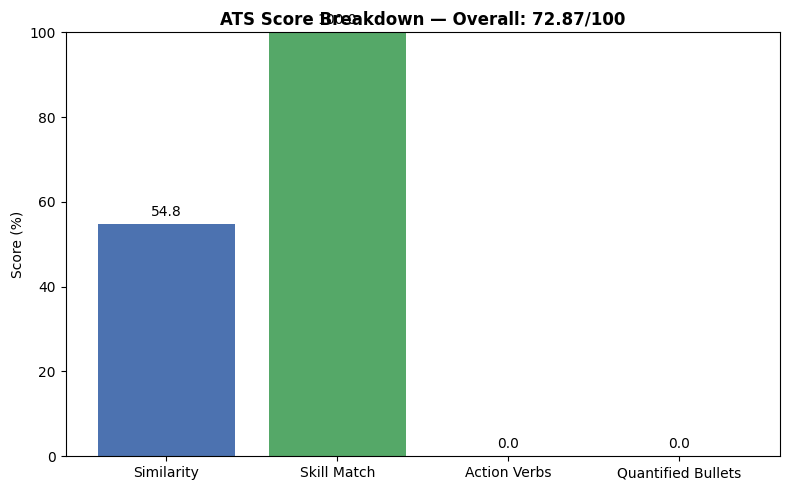

In [64]:
# ============================================
# 8. Full ATS Report Pipeline (Enhanced)
# ============================================
def full_ats_report(resume_text, job_description, show_plot=True):
    """
    Runs the complete enhanced ATS pipeline:
    - TF-IDF similarity + skill match (base score, from calculate_ats_score)
    - Section-aware parsing
    - Formatting/structure checks
    - Action verb & quantification check
    - Experience-level match
    - Feedback generation
    - Visualization
    """
    ats_result = calculate_ats_score(resume_text, job_description)

    sections = extract_resume_sections(resume_text)
    formatting_checks = check_resume_formatting(resume_text, sections)
    verb_metrics = check_action_verbs_and_metrics(resume_text)
    experience_check = check_experience_match(resume_text, job_description)
    feedback = generate_feedback(ats_result, resume_text, job_description)

    if not formatting_checks['has_email'] or not formatting_checks['has_phone']:
        feedback.append("**Tip:** Make sure your contact info (email & phone) is clearly visible near the top.")
    if not formatting_checks['has_skills_section']:
        feedback.append("**Tip:** Add a dedicated 'Skills' section — ATS systems weight this heavily.")
    if formatting_checks['length_flag'] == 'too_short':
        feedback.append("**Tip:** Your resume looks short — consider adding more detail on projects/experience.")
    elif formatting_checks['length_flag'] == 'too_long':
        feedback.append("**Tip:** Your resume looks long — consider trimming to 1-2 pages of the most relevant content.")
    if verb_metrics['action_verb_ratio'] < 0.3:
        feedback.append("**Tip:** Start more bullet points with strong action verbs (e.g. 'Led', 'Built', 'Improved').")
    if verb_metrics['quantified_ratio'] < 0.3:
        feedback.append("**Tip:** Quantify your achievements with numbers/percentages where possible (e.g. 'improved performance by 30%').")
    if experience_check['status'] == 'below_requirement':
        feedback.append(f"**Note:** Job requires ~{experience_check['required_years']}+ years; your resume shows ~{experience_check['candidate_years']} years.")

    report = {
        'ats_result': ats_result,
        'formatting_checks': formatting_checks,
        'action_verb_metrics': verb_metrics,
        'experience_check': experience_check,
        'feedback': feedback,
    }

    print("=" * 60)
    print("FULL ATS REPORT")
    print("=" * 60)
    print(f"Overall ATS Score : {ats_result['overall_score']} / 100")
    print(f"Similarity Score  : {ats_result['similarity_score']} / 100")
    print(f"Skill Match       : {ats_result['skill_match_percentage']}%")
    print(f"Contact Info      : Email={'OK' if formatting_checks['has_email'] else 'MISSING'}  Phone={'OK' if formatting_checks['has_phone'] else 'MISSING'}")
    print(f"Sections Found    : Skills={'OK' if formatting_checks['has_skills_section'] else 'MISSING'}  "
          f"Experience={'OK' if formatting_checks['has_experience_section'] else 'MISSING'}  "
          f"Education={'OK' if formatting_checks['has_education_section'] else 'MISSING'}")
    print(f"Action Verb Ratio : {verb_metrics['action_verb_ratio']*100:.0f}%")
    print(f"Quantified Ratio  : {verb_metrics['quantified_ratio']*100:.0f}%")
    print(f"Experience Match  : {experience_check['candidate_years']} yrs vs required {experience_check['required_years']} yrs ({experience_check['status']})")

    print("\nFeedback & Suggestions:")
    for line in feedback:
        print(f"   {line}")

    if show_plot:
        plot_score_breakdown(ats_result, verb_metrics)

    return report


# --- Demo run with the enhanced pipeline ---
print("\nRunning enhanced ATS pipeline on sample resume/job description...\n")
enhanced_report = full_ats_report(sample_resume, sample_job_description)


In [65]:
# ============================================
# Automated ATS Test Suite
# ============================================

test_results = []

def run_test(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    test_results.append((name, status, detail))
    print(f"[{status}] {name}" + (f" -- {detail}" if detail else ""))


print("=" * 60)
print("RUNNING ATS TEST SUITE")
print("=" * 60)

job_desc_test = """
Looking for a Senior Data Scientist with strong Python skills.
Must have experience in Machine Learning, Deep Learning, and NLP.
Experience with TensorFlow, PyTorch, and cloud platforms like AWS is a plus.
Should be proficient in Data Analysis and have knowledge of Docker.
5+ years of experience required.
"""

# ---- Test 1: Near-perfect match should score high ----
strong_resume = """
Senior Data Scientist with 6 years of experience in Python, Machine Learning,
Deep Learning, and NLP. Extensive hands-on work with TensorFlow, PyTorch,
Data Analysis, AWS, and Docker.
"""
r1 = calculate_ats_score(strong_resume, job_desc_test)
run_test(
    "Near-perfect match scores high (>=70)",
    r1['overall_score'] >= 70,
    f"got {r1['overall_score']}"
)

# ---- Test 2: Irrelevant resume should score low ----
irrelevant_resume = """
Experienced pastry chef with 10 years in French cuisine, cake decoration,
menu planning, and kitchen management. Skilled in food safety and catering.
"""
r2 = calculate_ats_score(irrelevant_resume, job_desc_test)
run_test(
    "Irrelevant resume scores low (<40)",
    r2['overall_score'] < 40,
    f"got {r2['overall_score']}"
)

# ---- Test 3: Monotonicity -- adding matching skills should not lower the score ----
base_resume = "Data professional with Python experience."
r3a = calculate_ats_score(base_resume, job_desc_test)
r3b = calculate_ats_score(base_resume + " Also skilled in Machine Learning and AWS.", job_desc_test)
run_test(
    "Adding matching skills does not decrease score",
    r3b['overall_score'] >= r3a['overall_score'],
    f"before={r3a['overall_score']}, after={r3b['overall_score']}"
)

# ---- Test 4: Empty inputs should not crash and should score low ----
try:
    r4 = calculate_ats_score("", job_desc_test)
    empty_ok = r4['overall_score'] < 40
    run_test("Empty resume does not crash and scores low", empty_ok, f"got {r4['overall_score']}")
except Exception as e:
    run_test("Empty resume does not crash and scores low", False, f"raised {type(e).__name__}: {e}")

try:
    r5 = calculate_ats_score(strong_resume, "")
    run_test("Empty job description does not crash", True, f"got {r5['overall_score']}")
except Exception as e:
    run_test("Empty job description does not crash", False, f"raised {type(e).__name__}: {e}")

# ---- Test 5: Formatting checks correctly detect missing info ----
bad_format_resume = """
Worked on various projects using Python and machine learning techniques
for several years across different companies and industries.
"""
fmt_checks = check_resume_formatting(bad_format_resume)
run_test(
    "Missing email is detected",
    fmt_checks['has_email'] == False,
    f"has_email={fmt_checks['has_email']}"
)
run_test(
    "Missing phone is detected",
    fmt_checks['has_phone'] == False,
    f"has_phone={fmt_checks['has_phone']}"
)
run_test(
    "Missing Skills section is detected",
    fmt_checks['has_skills_section'] == False,
    f"has_skills_section={fmt_checks['has_skills_section']}"
)

# ---- Test 6: Formatting checks correctly detect present info ----
good_format_resume = """
Jane Doe
Email: jane.doe@example.com | Phone: +1-555-123-4567

SKILLS:
Python, Machine Learning, AWS

EXPERIENCE:
Data Scientist at TechCo (2020-Present)

EDUCATION:
BSc Computer Science
"""
fmt_checks_good = check_resume_formatting(good_format_resume)
run_test(
    "Present email is detected",
    fmt_checks_good['has_email'] == True
)
run_test(
    "Present phone is detected",
    fmt_checks_good['has_phone'] == True
)
run_test(
    "Present Skills/Experience/Education sections are detected",
    fmt_checks_good['has_skills_section'] and fmt_checks_good['has_experience_section'] and fmt_checks_good['has_education_section']
)

# ---- Test 7: Experience match logic ----
exp_check = check_experience_match(strong_resume, job_desc_test)
run_test(
    "Experience match correctly flags candidate meeting requirement (6 yrs >= 5 yrs)",
    exp_check['status'] == 'meets_requirement',
    f"candidate={exp_check['candidate_years']}, required={exp_check['required_years']}, status={exp_check['status']}"
)

junior_resume = "Data Scientist with 2 years of experience in Python and Machine Learning."
exp_check_junior = check_experience_match(junior_resume, job_desc_test)
run_test(
    "Experience match correctly flags candidate below requirement (2 yrs < 5 yrs)",
    exp_check_junior['status'] == 'below_requirement',
    f"candidate={exp_check_junior['candidate_years']}, required={exp_check_junior['required_years']}, status={exp_check_junior['status']}"
)

# ---- Test 8: Advanced skill extraction catches synonyms ----
synonym_resume = "Experienced in ML, DL, JS, and K8s deployments."
advanced_skills = extract_skills_advanced(synonym_resume)
run_test(
    "Synonym matching resolves ML/DL/JS/K8s to canonical skills",
    {'machine learning', 'deep learning', 'javascript', 'kubernetes'}.issubset(advanced_skills),
    f"found={advanced_skills}"
)

# ---- Test 9: Action verb / quantification detection ----
strong_bullets_resume = """
- Led a team of 5 engineers to deliver the project 20% faster
- Improved system performance by 35%
- Reduced costs by $50000 annually
"""
verb_check = check_action_verbs_and_metrics(strong_bullets_resume)
run_test(
    "Action verb ratio is high for strong bullet points",
    verb_check['action_verb_ratio'] >= 0.6,
    f"ratio={verb_check['action_verb_ratio']}"
)
run_test(
    "Quantified ratio is high for bullets with numbers/percentages",
    verb_check['quantified_ratio'] >= 0.6,
    f"ratio={verb_check['quantified_ratio']}"
)

# ---- Summary ----
print("\n" + "=" * 60)
passed = sum(1 for _, status, _ in test_results if status == "PASS")
total = len(test_results)
print(f"TEST SUMMARY: {passed}/{total} passed")
print("=" * 60)

if passed < total:
    print("\nFailed tests:")
    for name, status, detail in test_results:
        if status == "FAIL":
            print(f"   - {name} ({detail})")


RUNNING ATS TEST SUITE
[PASS] Near-perfect match scores high (>=70) -- got 83.03
[PASS] Irrelevant resume scores low (<40) -- got 1.77
[PASS] Adding matching skills does not decrease score -- before=21.67, after=36.89
[PASS] Empty resume does not crash and scores low -- got 0.0
[PASS] Empty job description does not crash -- got 0.0
[PASS] Missing email is detected -- has_email=False
[PASS] Missing phone is detected -- has_phone=False
[PASS] Missing Skills section is detected -- has_skills_section=False
[PASS] Present email is detected
[PASS] Present phone is detected
[PASS] Present Skills/Experience/Education sections are detected
[PASS] Experience match correctly flags candidate meeting requirement (6 yrs >= 5 yrs) -- candidate=6, required=5, status=meets_requirement
[PASS] Experience match correctly flags candidate below requirement (2 yrs < 5 yrs) -- candidate=2, required=5, status=below_requirement
[PASS] Synonym matching resolves ML/DL/JS/K8s to canonical skills -- found={'javascr